# Analysis: GPU-side Newton-Raphson (Fast NR Inner Loop)

**Comparison of:** `2026_03_16_bl_estimation_fused` (F1 baseline) vs `2026_03_16_bl_estimation_gpu_NR` (NR: GPU-side Newton-Raphson)  
**Also compared against:** `2026_03_16_bl_estimation` (CPU-48 reference) for overall GPU vs CPU standing  
**Dataset:** 100 taxa, 1M sites, 10 different trees, 10 runs each  
**Backend:** OPENACC (GPU V100)  
**Models:** DNA/GTR unrooted, AA/LG unrooted  

**Change:** Replaced standard `optimizeOneBranch` → `minimizeNewton` → `computeFuncDerv` → `computeLikelihoodDerv` chain with fused `optimizeOneBranchOpenACC` that:  
- Calls `computeTraversalInfo` and `uploadEigenToGPU` **once** per branch (not per NR iteration)  
- Computes P(t)/P'(t)/P''(t) on GPU via `computeTransDerivOnGPU` (TIP-INT was host-side before)  
- Computes tip derivative tables on GPU via `computeTipDerivTablesOnGPU` (was dead code, now activated)  
- Inlines NR loop with identical convergence criteria and bisection fallback  
- Eliminates ~100-500μs overhead per NR iteration (uploadEigen, host P(t), tip table host compute + upload)

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cwd = os.getcwd()
f1_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation_fused"
nr_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation_gpu_NR"
cpu_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation"  # has CPU-48 results

# 1. Parse all log files

In [2]:
alignment_pattern = re.compile(r"Alignment has (\d+) sequences with (\d+) columns, (\d+) distinct patterns")
initial_ll_pattern = re.compile(r"Initial log-likelihood:\s+([-0-9.]+)")
optimal_ll_pattern = re.compile(r"Optimal log-likelihood:\s+([-0-9.]+)")
params_opt_pattern = re.compile(r"Parameters optimization took (\d+) rounds? \(([0-9.]+) sec\)")
wallclock_pattern = re.compile(r"Total wall-clock time used:\s+([0-9.]+)\s+sec")

In [3]:
def parse_all_logs(results_path, source_label="baseline"):
    """Parse all IQ-TREE log files and extract timing/likelihood data."""
    rows = []
    skipped = 0

    for data_type in ['AA', 'DNA']:
        data_dir = os.path.join(results_path, data_type)
        if not os.path.exists(data_dir):
            continue

        for tree_type in ['rooted', 'unrooted']:
            tree_type_dir = os.path.join(data_dir, tree_type)
            if not os.path.exists(tree_type_dir):
                continue

            for model in sorted(os.listdir(tree_type_dir)):
                model_dir = os.path.join(tree_type_dir, model)
                if not os.path.isdir(model_dir):
                    continue

                for tree_folder in sorted(os.listdir(model_dir)):
                    tree_dir = os.path.join(model_dir, tree_folder)
                    if not os.path.isdir(tree_dir):
                        continue

                    for fname in os.listdir(tree_dir):
                        if not fname.endswith('.log'):
                            continue

                        filepath = os.path.join(tree_dir, fname)
                        with open(filepath, 'r') as f:
                            content = f.read()

                        if 'OPENACC' in fname:
                            backend = 'GPU_V100'
                        elif 'OMP_48' in fname:
                            backend = 'CPU_48cores'
                        elif 'OMP_10' in fname:
                            backend = 'CPU_10cores'
                        elif 'VANILA' in fname:
                            backend = 'CPU_1core'
                        else:
                            continue

                        run_matches = re.findall(r'_run(\d+)_', fname)
                        run_number = int(run_matches[-1]) if run_matches else None

                        aln_match = alignment_pattern.search(content)
                        init_ll_match = initial_ll_pattern.search(content)
                        opt_ll_match = optimal_ll_pattern.search(content)
                        opt_match = params_opt_pattern.search(content)
                        wc_match = wallclock_pattern.search(content)

                        if aln_match and init_ll_match and opt_match and wc_match:
                            rows.append({
                                'source': source_label,
                                'data_type': data_type,
                                'tree_type': tree_type,
                                'model': model,
                                'treefile': tree_folder,
                                'backend': backend,
                                'run': run_number,
                                'taxa': int(aln_match.group(1)),
                                'sites': int(aln_match.group(2)),
                                'patterns': int(aln_match.group(3)),
                                'initial_likelihood': float(init_ll_match.group(1)),
                                'optimal_likelihood': float(opt_ll_match.group(1)) if opt_ll_match else float(init_ll_match.group(1)),
                                'opt_rounds': int(opt_match.group(1)),
                                'opt_time': float(opt_match.group(2)),
                                'wallclock_time': float(wc_match.group(1)),
                            })
                        else:
                            skipped += 1

    df = pd.DataFrame(rows)
    print(f"[{source_label}] Parsed {len(df)} log files ({skipped} skipped)")
    return df

df_f1 = parse_all_logs(f1_path, "F1 (baseline)")
df_nr = parse_all_logs(nr_path, "NR (GPU NR)")
# CPU-48 reference — filter to LG and GTR models only (matching GPU test)
df_cpu_all = parse_all_logs(cpu_path, "CPU-48")
df_cpu = df_cpu_all[(df_cpu_all['backend'] == 'CPU_48cores') & 
                     (df_cpu_all['model'].isin(['LG', 'GTR']))].copy()

[F1 (baseline)] Parsed 200 log files (0 skipped)
[NR (GPU NR)] Parsed 196 log files (1 skipped)
[CPU-48] Parsed 6396 log files (4 skipped)


# 2. Data overview

In [4]:
print("=== F1 (baseline) data breakdown ===")
print(df_f1.groupby(['data_type','tree_type','model','backend']).size().reset_index(name='count'))
print(f"\n=== NR (GPU NR) data breakdown ===")
print(df_nr.groupby(['data_type','tree_type','model','backend']).size().reset_index(name='count'))
if len(df_cpu) > 0:
    print(f"\n=== CPU-48 reference data breakdown ===")
    print(df_cpu.groupby(['data_type','tree_type','model','backend']).size().reset_index(name='count'))

# Combine GPU results
df_all = pd.concat([df_f1, df_nr], ignore_index=True)
df_all['combo'] = df_all['data_type'] + '\n' + df_all['model'] + '\n' + df_all['tree_type']

=== F1 (baseline) data breakdown ===
  data_type tree_type model   backend  count
0        AA  unrooted    LG  GPU_V100    100
1       DNA  unrooted   GTR  GPU_V100    100

=== NR (GPU NR) data breakdown ===
  data_type tree_type model   backend  count
0        AA  unrooted    LG  GPU_V100    100
1       DNA  unrooted   GTR  GPU_V100     96

=== CPU-48 reference data breakdown ===
  data_type tree_type model      backend  count
0        AA    rooted    LG  CPU_48cores    100
1        AA  unrooted    LG  CPU_48cores    100
2       DNA    rooted   GTR  CPU_48cores    100
3       DNA  unrooted   GTR  CPU_48cores    100


# 3. Statistical comparison

In [5]:
print("=" * 80)
print("COMPARISON: F1 (baseline) vs NR (GPU-side Newton-Raphson)")
print("  F1 = standard optimizeOneBranch (full computeLikelihoodDerv per NR step)")
print("  NR = fused optimizeOneBranchOpenACC (eliminated per-step overhead)")
print("=" * 80)

combos = df_nr[['data_type','tree_type','model','backend']].drop_duplicates()

for _, combo in combos.iterrows():
    dt, tt, model, backend = combo['data_type'], combo['tree_type'], combo['model'], combo['backend']
    f1_sub = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                   (df_f1['model']==model) & (df_f1['backend']==backend)]
    nr_sub = df_nr[(df_nr['data_type']==dt) & (df_nr['tree_type']==tt) & 
                   (df_nr['model']==model) & (df_nr['backend']==backend)]
    
    print(f"\n--- {dt} | {tt} | {model} | {backend} ---")
    print(f"  F1:  n={len(f1_sub)}, wallclock median={f1_sub['wallclock_time'].median():.3f}s, "
          f"mean={f1_sub['wallclock_time'].mean():.3f}s, std={f1_sub['wallclock_time'].std():.3f}s")
    print(f"  NR:  n={len(nr_sub)}, wallclock median={nr_sub['wallclock_time'].median():.3f}s, "
          f"mean={nr_sub['wallclock_time'].mean():.3f}s, std={nr_sub['wallclock_time'].std():.3f}s")
    if f1_sub['wallclock_time'].median() > 0:
        pct = (nr_sub['wallclock_time'].median() - f1_sub['wallclock_time'].median()) / f1_sub['wallclock_time'].median() * 100
        print(f"  Wallclock change (median): {pct:+.2f}%")
    
    # opt_time comparison
    if len(f1_sub) > 0 and 'opt_time' in f1_sub.columns:
        print(f"  F1 opt_time: median={f1_sub['opt_time'].median():.3f}s, mean={f1_sub['opt_time'].mean():.3f}s")
        print(f"  NR opt_time: median={nr_sub['opt_time'].median():.3f}s, mean={nr_sub['opt_time'].mean():.3f}s")
        pct2 = (nr_sub['opt_time'].median() - f1_sub['opt_time'].median()) / f1_sub['opt_time'].median() * 100
        print(f"  Opt_time change (median): {pct2:+.2f}%")
    
    # CPU-48 comparison
    cpu_sub = df_cpu[(df_cpu['data_type']==dt) & (df_cpu['tree_type']==tt) & 
                     (df_cpu['model']==model) & (df_cpu['backend']=='CPU_48cores')]
    if len(cpu_sub) > 0:
        cpu_med = cpu_sub['wallclock_time'].median()
        nr_med = nr_sub['wallclock_time'].median()
        ratio = nr_med / cpu_med
        print(f"  CPU-48 wallclock median: {cpu_med:.3f}s")
        print(f"  GPU/CPU-48 ratio: {ratio:.2f}x {'(GPU slower)' if ratio > 1 else '(GPU FASTER!)'}")
    
    # LL comparison
    print(f"  F1 optimal_LL: {sorted(f1_sub['optimal_likelihood'].unique())}")
    print(f"  NR optimal_LL: {sorted(nr_sub['optimal_likelihood'].unique())}")
    f1_lls = set(f1_sub['optimal_likelihood'].unique())
    nr_lls = set(nr_sub['optimal_likelihood'].unique())
    if f1_lls == nr_lls:
        print(f"  LL match: YES (exact match)")
    else:
        f1_sorted = sorted(f1_sub['optimal_likelihood'].unique())
        nr_sorted = sorted(nr_sub['optimal_likelihood'].unique())
        if len(f1_sorted) == len(nr_sorted):
            max_diff = max(abs(a - b) for a, b in zip(f1_sorted, nr_sorted))
            print(f"  LL match: NO — max diff = {max_diff:.6f}")
        else:
            print(f"  LL match: NO — different number of unique values!")

COMPARISON: F1 (baseline) vs NR (GPU-side Newton-Raphson)
  F1 = standard optimizeOneBranch (full computeLikelihoodDerv per NR step)
  NR = fused optimizeOneBranchOpenACC (eliminated per-step overhead)

--- AA | unrooted | LG | GPU_V100 ---
  F1:  n=100, wallclock median=18.697s, mean=18.101s, std=1.342s
  NR:  n=100, wallclock median=14.072s, mean=14.685s, std=1.289s
  Wallclock change (median): -24.73%
  F1 opt_time: median=15.838s, mean=15.237s
  NR opt_time: median=11.218s, mean=11.815s
  Opt_time change (median): -29.17%
  CPU-48 wallclock median: 15.169s
  GPU/CPU-48 ratio: 0.93x (GPU FASTER!)
  F1 optimal_LL: [-90504713.177, -88901422.374, -87712627.079, -87357001.171, -87134163.126, -86714228.485, -86382770.364, -84301496.968, -82340194.25, -81931521.002]
  NR optimal_LL: [-90504760.789, -88901466.921, -87712679.44, -87357053.759, -87134222.049, -86714281.628, -86382823.162, -84301546.823, -82340240.018, -81931569.493]
  LL match: NO — max diff = 58.923000

--- DNA | unrooted |

# 4. Plot setup

In [6]:
SOURCE_PALETTE = {'F1 (baseline)': '#1565C0', 'NR (GPU NR)': '#C62828'}

sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'font.size': 13,
    'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 11, 'figure.titlesize': 16,
    'axes.linewidth': 1.2, 'lines.linewidth': 2,
    'savefig.bbox': 'tight', 'savefig.pad_inches': 0.15,
    'figure.facecolor': 'white', 'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
})

# 5. Wall-clock time per tree

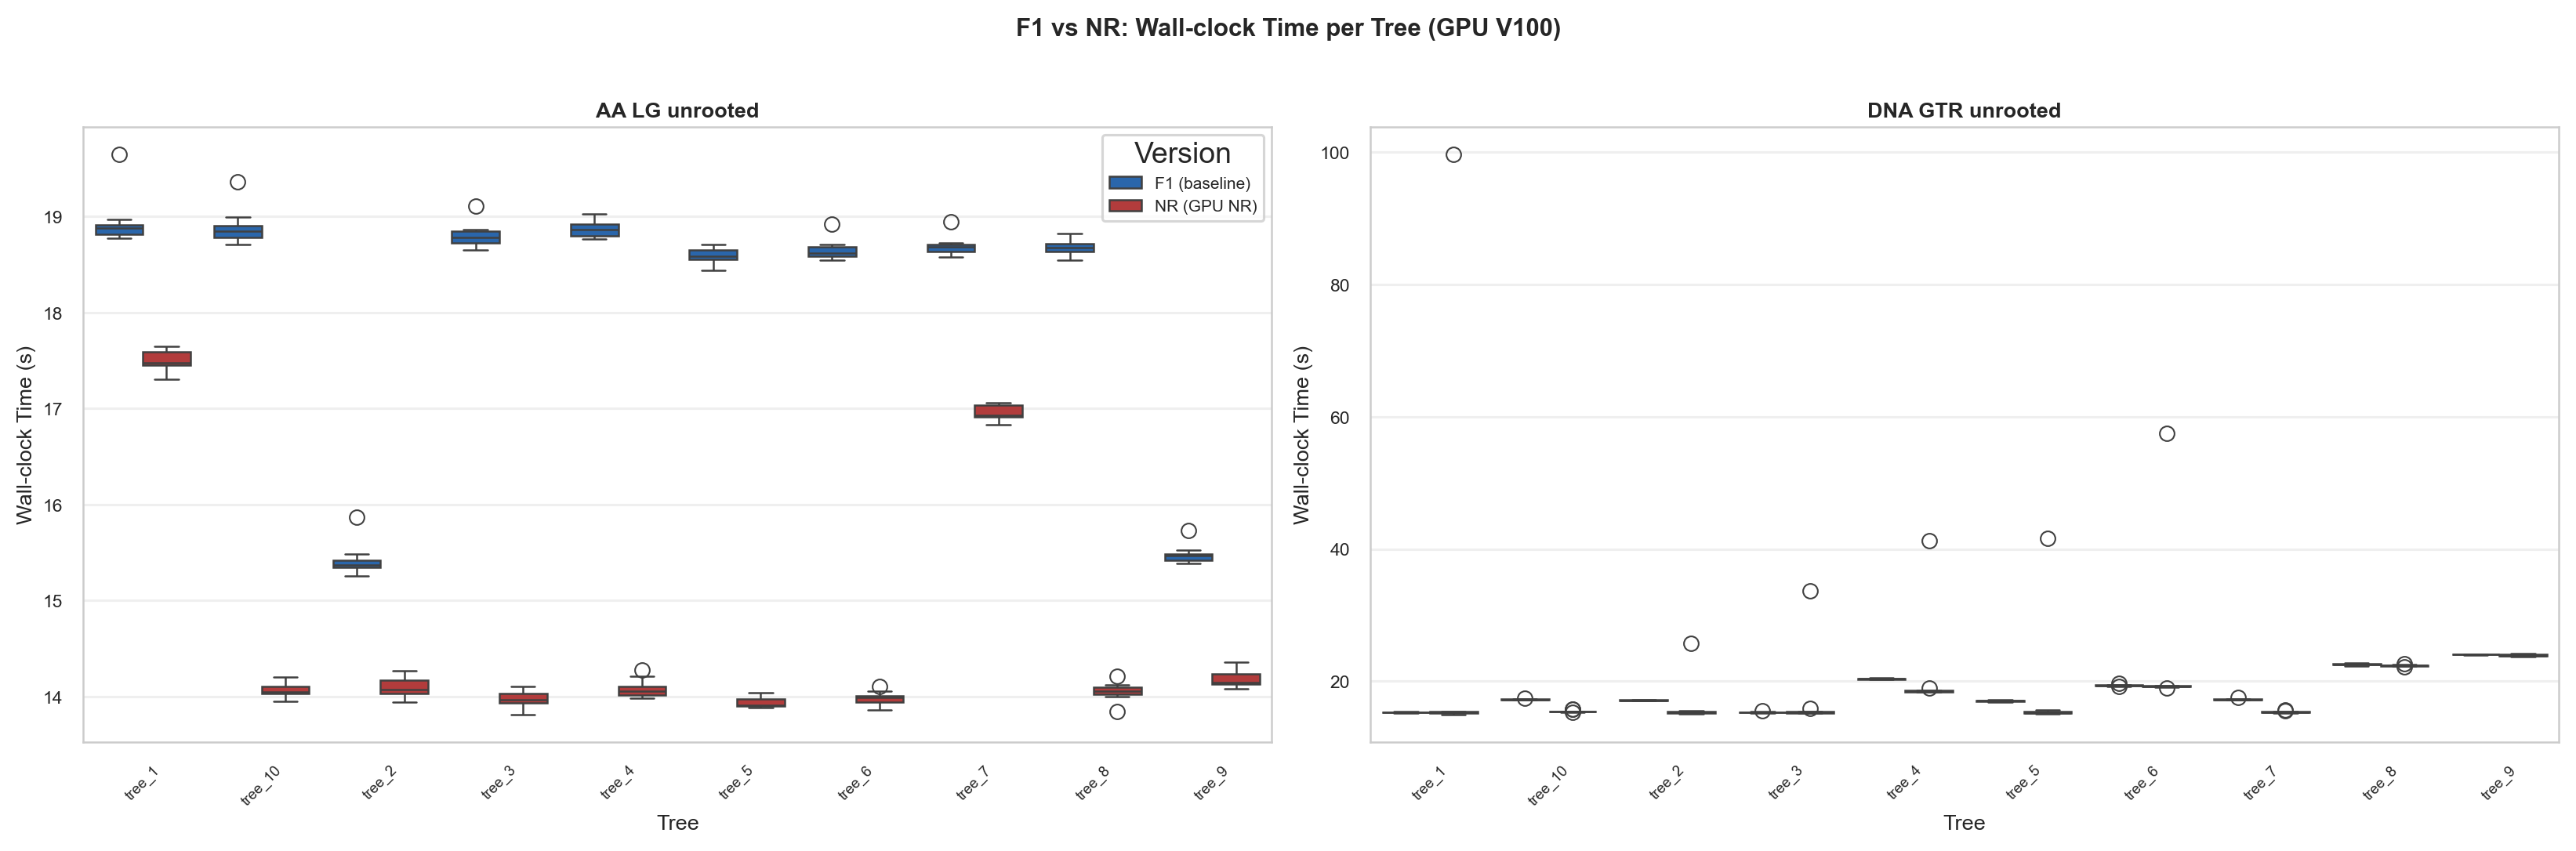

In [7]:
combos = df_nr[['data_type','tree_type','model']].drop_duplicates()
n_combos = len(combos)
fig, axes = plt.subplots(1, n_combos, figsize=(11 * n_combos, 7))
if n_combos == 1:
    axes = [axes]

for idx, (_, combo) in enumerate(combos.iterrows()):
    dt, tt, model = combo['data_type'], combo['tree_type'], combo['model']
    subset = df_all[(df_all['data_type']==dt) & (df_all['tree_type']==tt) & (df_all['model']==model)]
    ax = axes[idx]
    sns.boxplot(data=subset, x='treefile', y='wallclock_time', hue='source',
                hue_order=['F1 (baseline)', 'NR (GPU NR)'], palette=SOURCE_PALETTE,
                linewidth=1.2, ax=ax)
    ax.set_title(f'{dt} {model} {tt}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tree')
    ax.set_ylabel('Wall-clock Time (s)')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    if idx > 0:
        ax.get_legend().remove()
    else:
        ax.legend(title='Version', fontsize=10)

plt.suptitle('F1 vs NR: Wall-clock Time per Tree (GPU V100)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_wallclock_per_tree.png", bbox_inches='tight', dpi=300)
plt.show()

# 6. Optimization time per tree

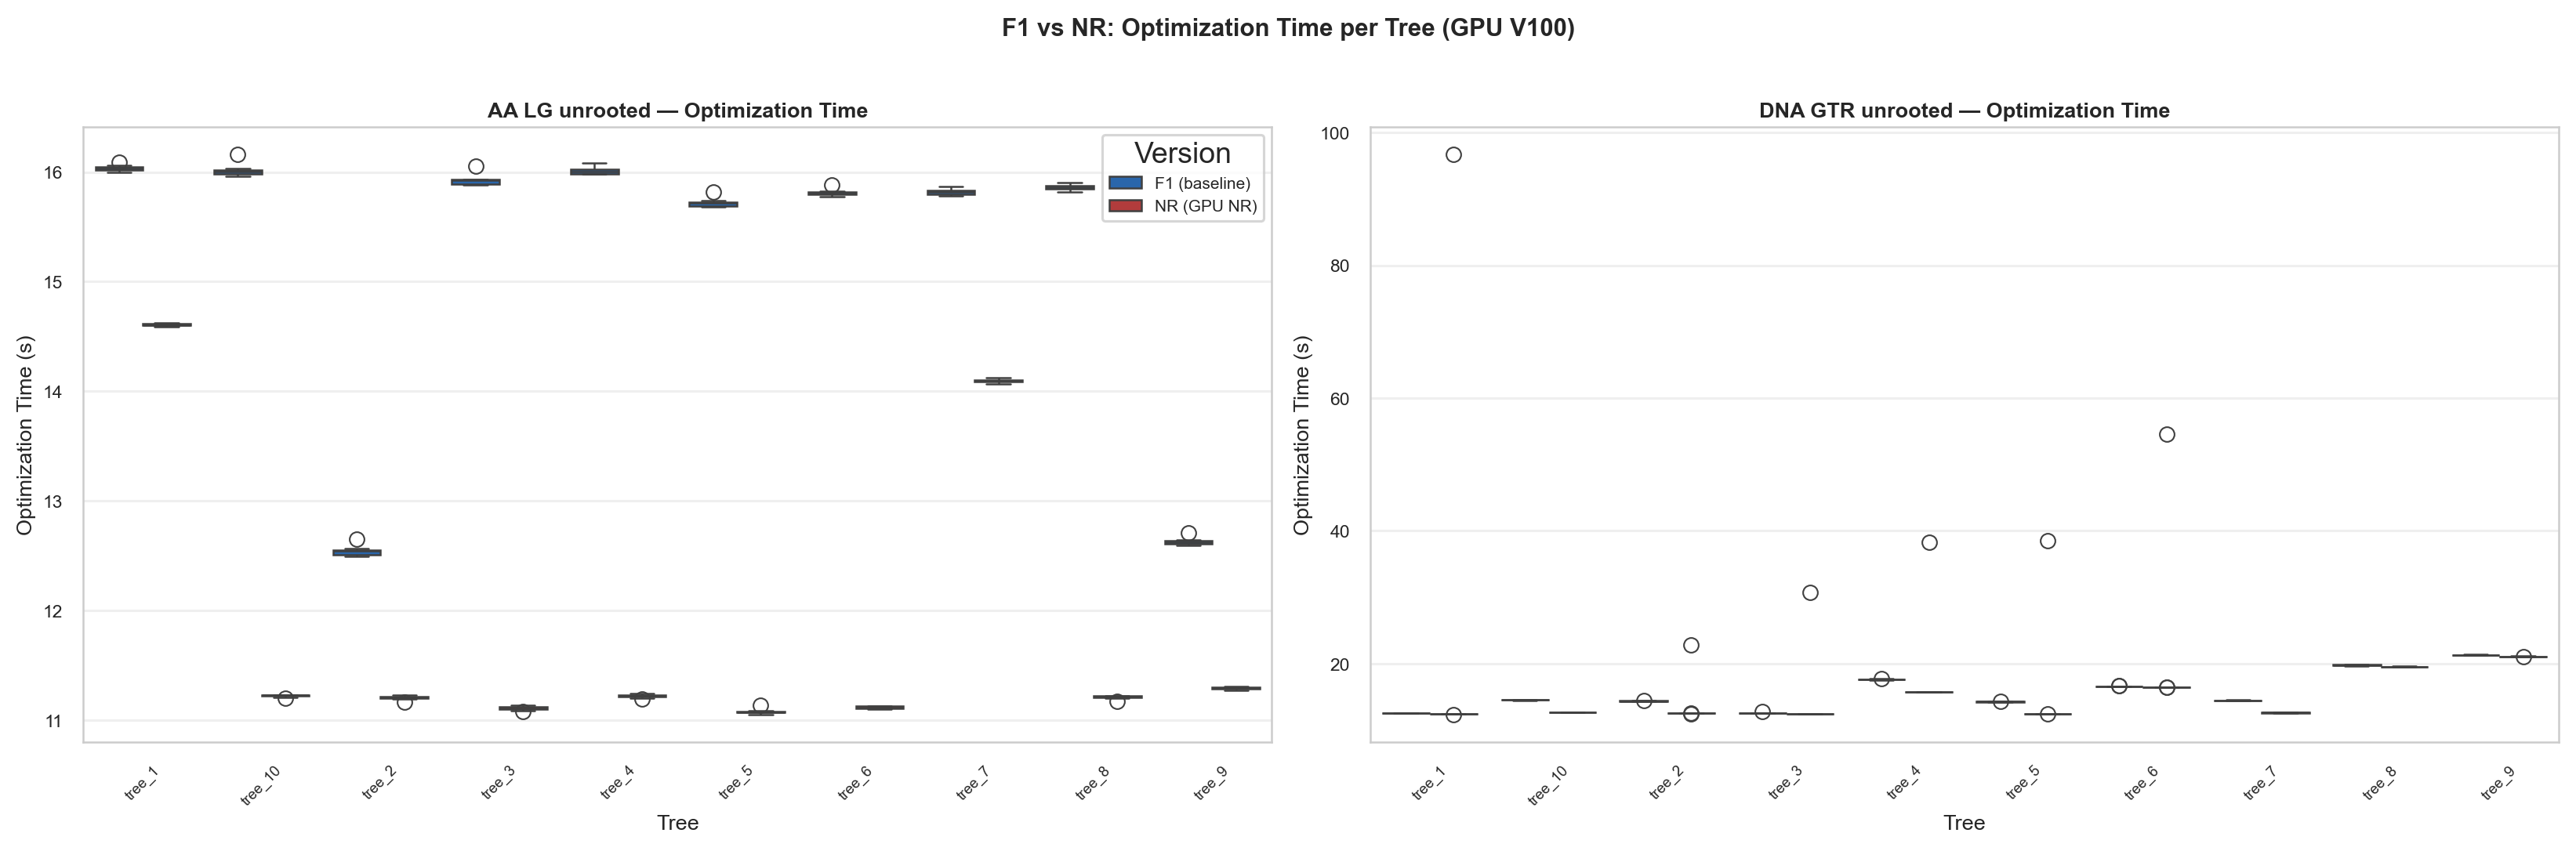

In [8]:
combos = df_nr[['data_type','tree_type','model']].drop_duplicates()
n_combos = len(combos)
fig, axes = plt.subplots(1, n_combos, figsize=(11 * n_combos, 7))
if n_combos == 1:
    axes = [axes]

for idx, (_, combo) in enumerate(combos.iterrows()):
    dt, tt, model = combo['data_type'], combo['tree_type'], combo['model']
    subset = df_all[(df_all['data_type']==dt) & (df_all['tree_type']==tt) & (df_all['model']==model)]
    ax = axes[idx]
    sns.boxplot(data=subset, x='treefile', y='opt_time', hue='source',
                hue_order=['F1 (baseline)', 'NR (GPU NR)'], palette=SOURCE_PALETTE,
                linewidth=1.2, ax=ax)
    ax.set_title(f'{dt} {model} {tt} \u2014 Optimization Time', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tree')
    ax.set_ylabel('Optimization Time (s)')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    if idx > 0:
        ax.get_legend().remove()
    else:
        ax.legend(title='Version', fontsize=10)

plt.suptitle('F1 vs NR: Optimization Time per Tree (GPU V100)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_opt_time_per_tree.png", bbox_inches='tight', dpi=300)
plt.show()

# 7. Aggregated comparison (wallclock + opt_time)

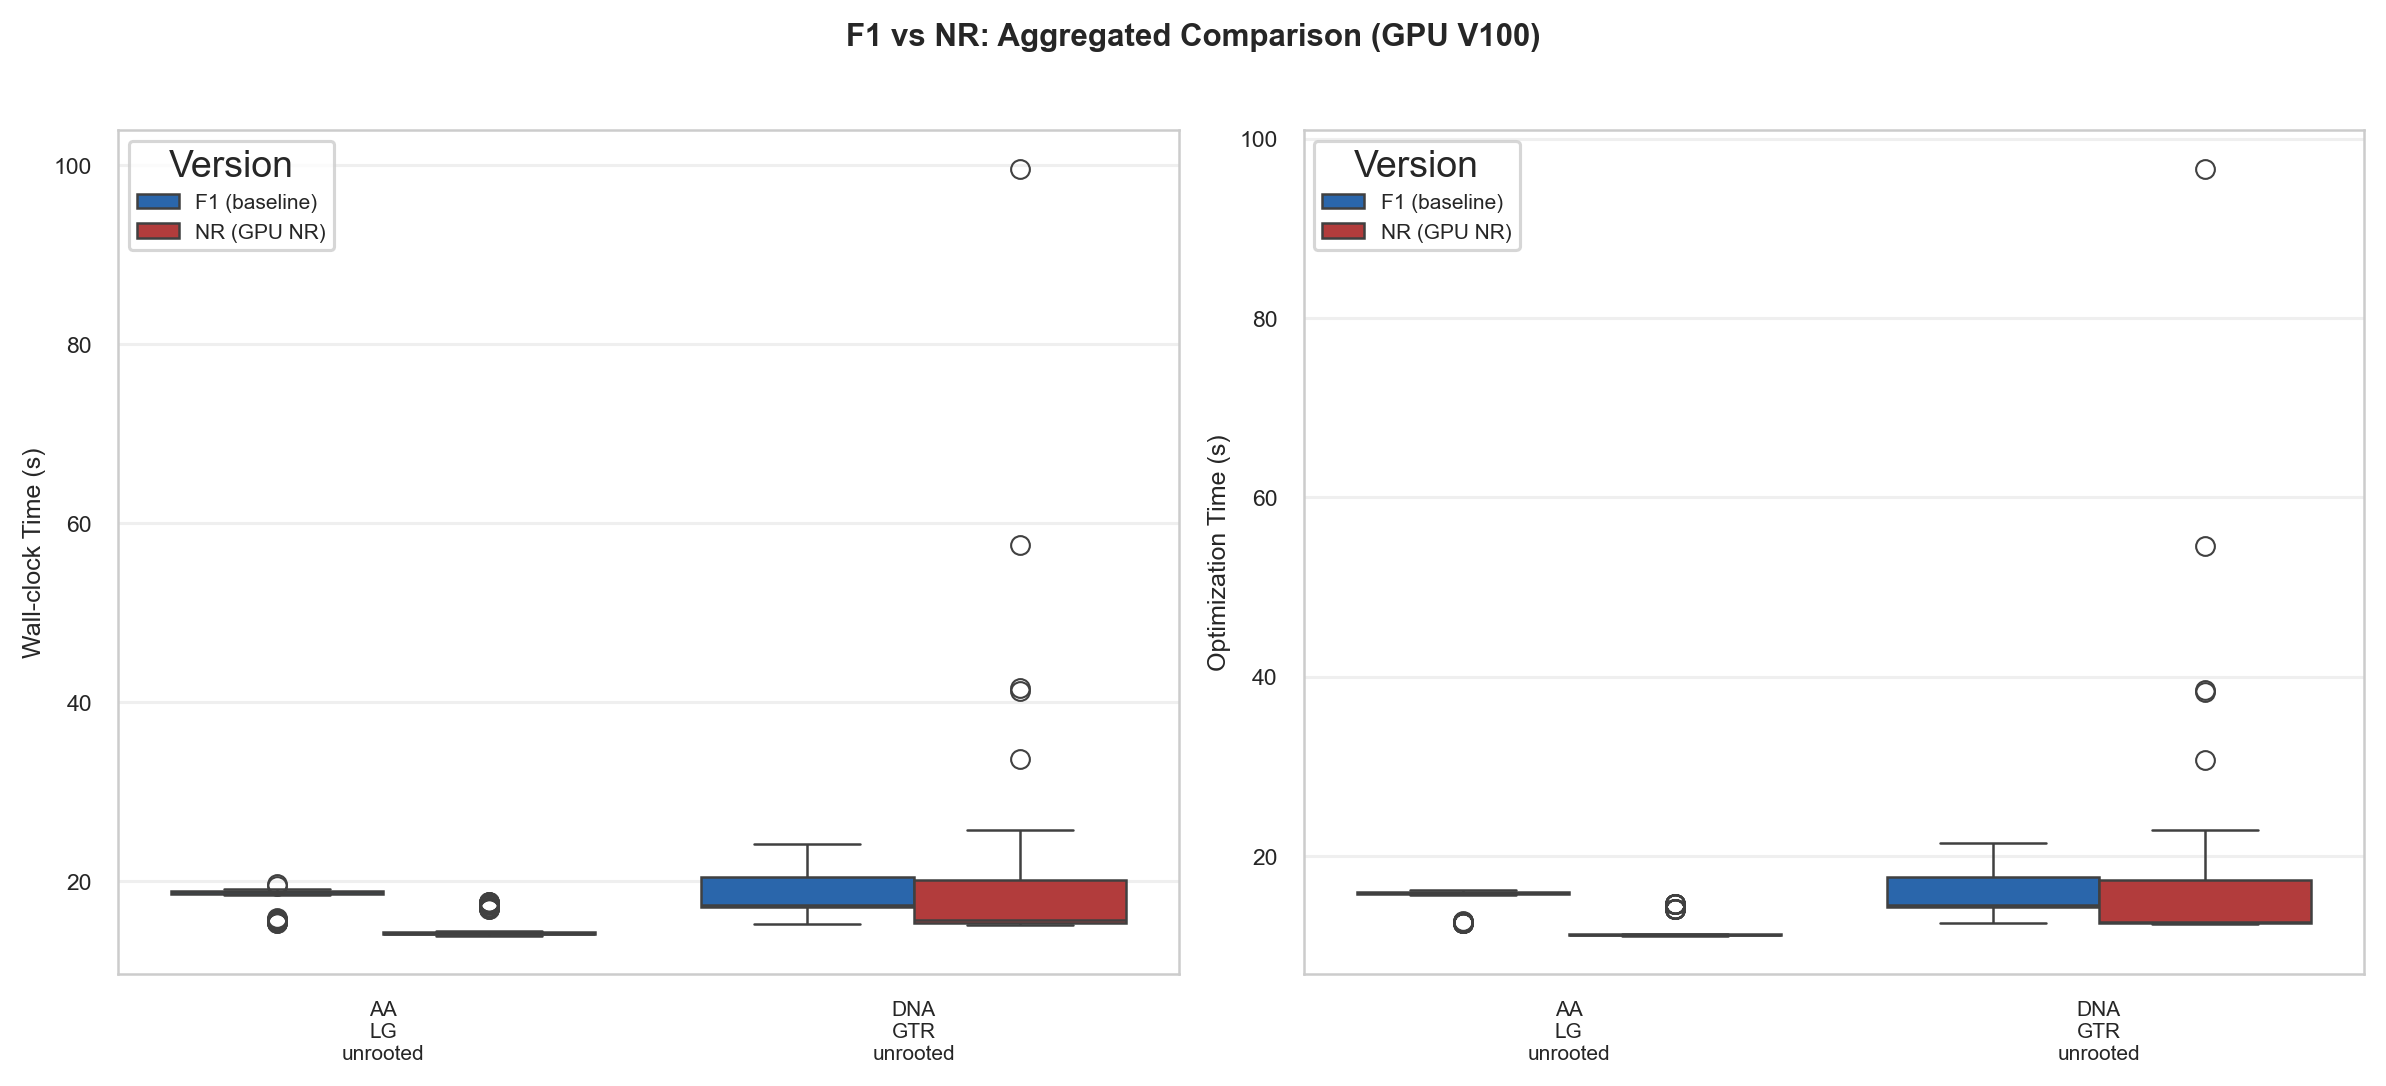

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, metric, label in [(ax1, 'wallclock_time', 'Wall-clock Time (s)'), 
                           (ax2, 'opt_time', 'Optimization Time (s)')]:
    sns.boxplot(data=df_all, x='combo', y=metric, hue='source',
                hue_order=['F1 (baseline)', 'NR (GPU NR)'], palette=SOURCE_PALETTE,
                linewidth=1.2, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel(label, fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(title='Version', fontsize=10)
    ax.tick_params(axis='x', labelsize=10)

plt.suptitle('F1 vs NR: Aggregated Comparison (GPU V100)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_aggregated.png", bbox_inches='tight', dpi=300)
plt.show()

# 8. Per-tree median comparison table

In [10]:
combos = df_nr[['data_type','tree_type','model','backend']].drop_duplicates()

for _, combo in combos.iterrows():
    dt, tt, model, backend = combo['data_type'], combo['tree_type'], combo['model'], combo['backend']
    print(f"\n{'='*90}")
    print(f"  {dt}/{model} ({tt}) \u2014 {backend}")
    print(f"{'='*90}")
    print(f"{'Tree':<10} {'F1 wc_med':>12} {'NR wc_med':>12} {'Diff (s)':>10} {'Change':>10} | {'F1 opt_med':>12} {'NR opt_med':>12} {'Opt chg':>10} {'LL match':>10}")
    print(f"{'-'*10} {'-'*12} {'-'*12} {'-'*10} {'-'*10} | {'-'*12} {'-'*12} {'-'*10} {'-'*10}")

    all_f1_wc = []
    all_nr_wc = []
    all_f1_opt = []
    all_nr_opt = []

    trees = sorted(set(df_f1[(df_f1['data_type']==dt) & (df_f1['model']==model)]['treefile'].unique()) |
                   set(df_nr[(df_nr['data_type']==dt) & (df_nr['model']==model)]['treefile'].unique()))

    for tree in trees:
        f1_wc = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                         (df_f1['model']==model) & (df_f1['treefile']==tree) &
                         (df_f1['backend']==backend)]['wallclock_time']
        nr_wc = df_nr[(df_nr['data_type']==dt) & (df_nr['tree_type']==tt) & 
                         (df_nr['model']==model) & (df_nr['treefile']==tree) &
                         (df_nr['backend']==backend)]['wallclock_time']
        f1_opt = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                         (df_f1['model']==model) & (df_f1['treefile']==tree) &
                         (df_f1['backend']==backend)]['opt_time']
        nr_opt = df_nr[(df_nr['data_type']==dt) & (df_nr['tree_type']==tt) & 
                         (df_nr['model']==model) & (df_nr['treefile']==tree) &
                         (df_nr['backend']==backend)]['opt_time']
        f1_lls = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                       (df_f1['model']==model) & (df_f1['treefile']==tree) &
                       (df_f1['backend']==backend)]['optimal_likelihood']
        nr_lls = df_nr[(df_nr['data_type']==dt) & (df_nr['tree_type']==tt) & 
                       (df_nr['model']==model) & (df_nr['treefile']==tree) &
                       (df_nr['backend']==backend)]['optimal_likelihood']

        if len(f1_wc) == 0 or len(nr_wc) == 0:
            continue

        f1_wc_med = f1_wc.median()
        nr_wc_med = nr_wc.median()
        f1_opt_med = f1_opt.median()
        nr_opt_med = nr_opt.median()
        diff = nr_wc_med - f1_wc_med
        pct = (diff / f1_wc_med) * 100
        opt_pct = (nr_opt_med - f1_opt_med) / f1_opt_med * 100
        ll_match = "YES" if set(f1_lls.unique()) == set(nr_lls.unique()) else "DIFF"
        # Check approximate match if not exact
        if ll_match == "DIFF":
            f1_s = sorted(f1_lls.unique())
            nr_s = sorted(nr_lls.unique())
            if len(f1_s) == len(nr_s):
                max_d = max(abs(a - b) for a, b in zip(f1_s, nr_s))
                if max_d < 1.0:
                    ll_match = f"~{max_d:.2f}"

        all_f1_wc.append(f1_wc_med)
        all_nr_wc.append(nr_wc_med)
        all_f1_opt.append(f1_opt_med)
        all_nr_opt.append(nr_opt_med)

        print(f"{tree:<10} {f1_wc_med:>12.3f} {nr_wc_med:>12.3f} {diff:>+10.3f} {pct:>+9.1f}% | {f1_opt_med:>12.3f} {nr_opt_med:>12.3f} {opt_pct:>+9.1f}% {ll_match:>10}")

    if all_f1_wc and all_nr_wc:
        avg_f1 = np.mean(all_f1_wc)
        avg_nr = np.mean(all_nr_wc)
        avg_f1_opt = np.mean(all_f1_opt)
        avg_nr_opt = np.mean(all_nr_opt)
        print(f"{'-'*10} {'-'*12} {'-'*12} {'-'*10} {'-'*10} | {'-'*12} {'-'*12} {'-'*10} {'-'*10}")
        print(f"{'MEAN':<10} {avg_f1:>12.3f} {avg_nr:>12.3f} {avg_nr-avg_f1:>+10.3f} {(avg_nr-avg_f1)/avg_f1*100:>+9.1f}% | {avg_f1_opt:>12.3f} {avg_nr_opt:>12.3f} {(avg_nr_opt-avg_f1_opt)/avg_f1_opt*100:>+9.1f}%")


  AA/LG (unrooted) — GPU_V100
Tree          F1 wc_med    NR wc_med   Diff (s)     Change |   F1 opt_med   NR opt_med    Opt chg   LL match
---------- ------------ ------------ ---------- ---------- | ------------ ------------ ---------- ----------
tree_1           18.878       17.480     -1.398      -7.4% |       16.035       14.603      -8.9%       DIFF
tree_10          18.850       14.047     -4.803     -25.5% |       16.006       11.226     -29.9%       DIFF
tree_2           15.373       14.075     -1.298      -8.4% |       12.543       11.206     -10.7%       DIFF
tree_3           18.781       13.967     -4.814     -25.6% |       15.928       11.110     -30.2%       DIFF
tree_4           18.867       14.059     -4.807     -25.5% |       16.001       11.221     -29.9%       DIFF
tree_5           18.586       13.914     -4.672     -25.1% |       15.715       11.075     -29.5%       DIFF
tree_6           18.620       13.989     -4.630     -24.9% |       15.805       11.118     -29.7%

# 9. Per-run speedup distribution

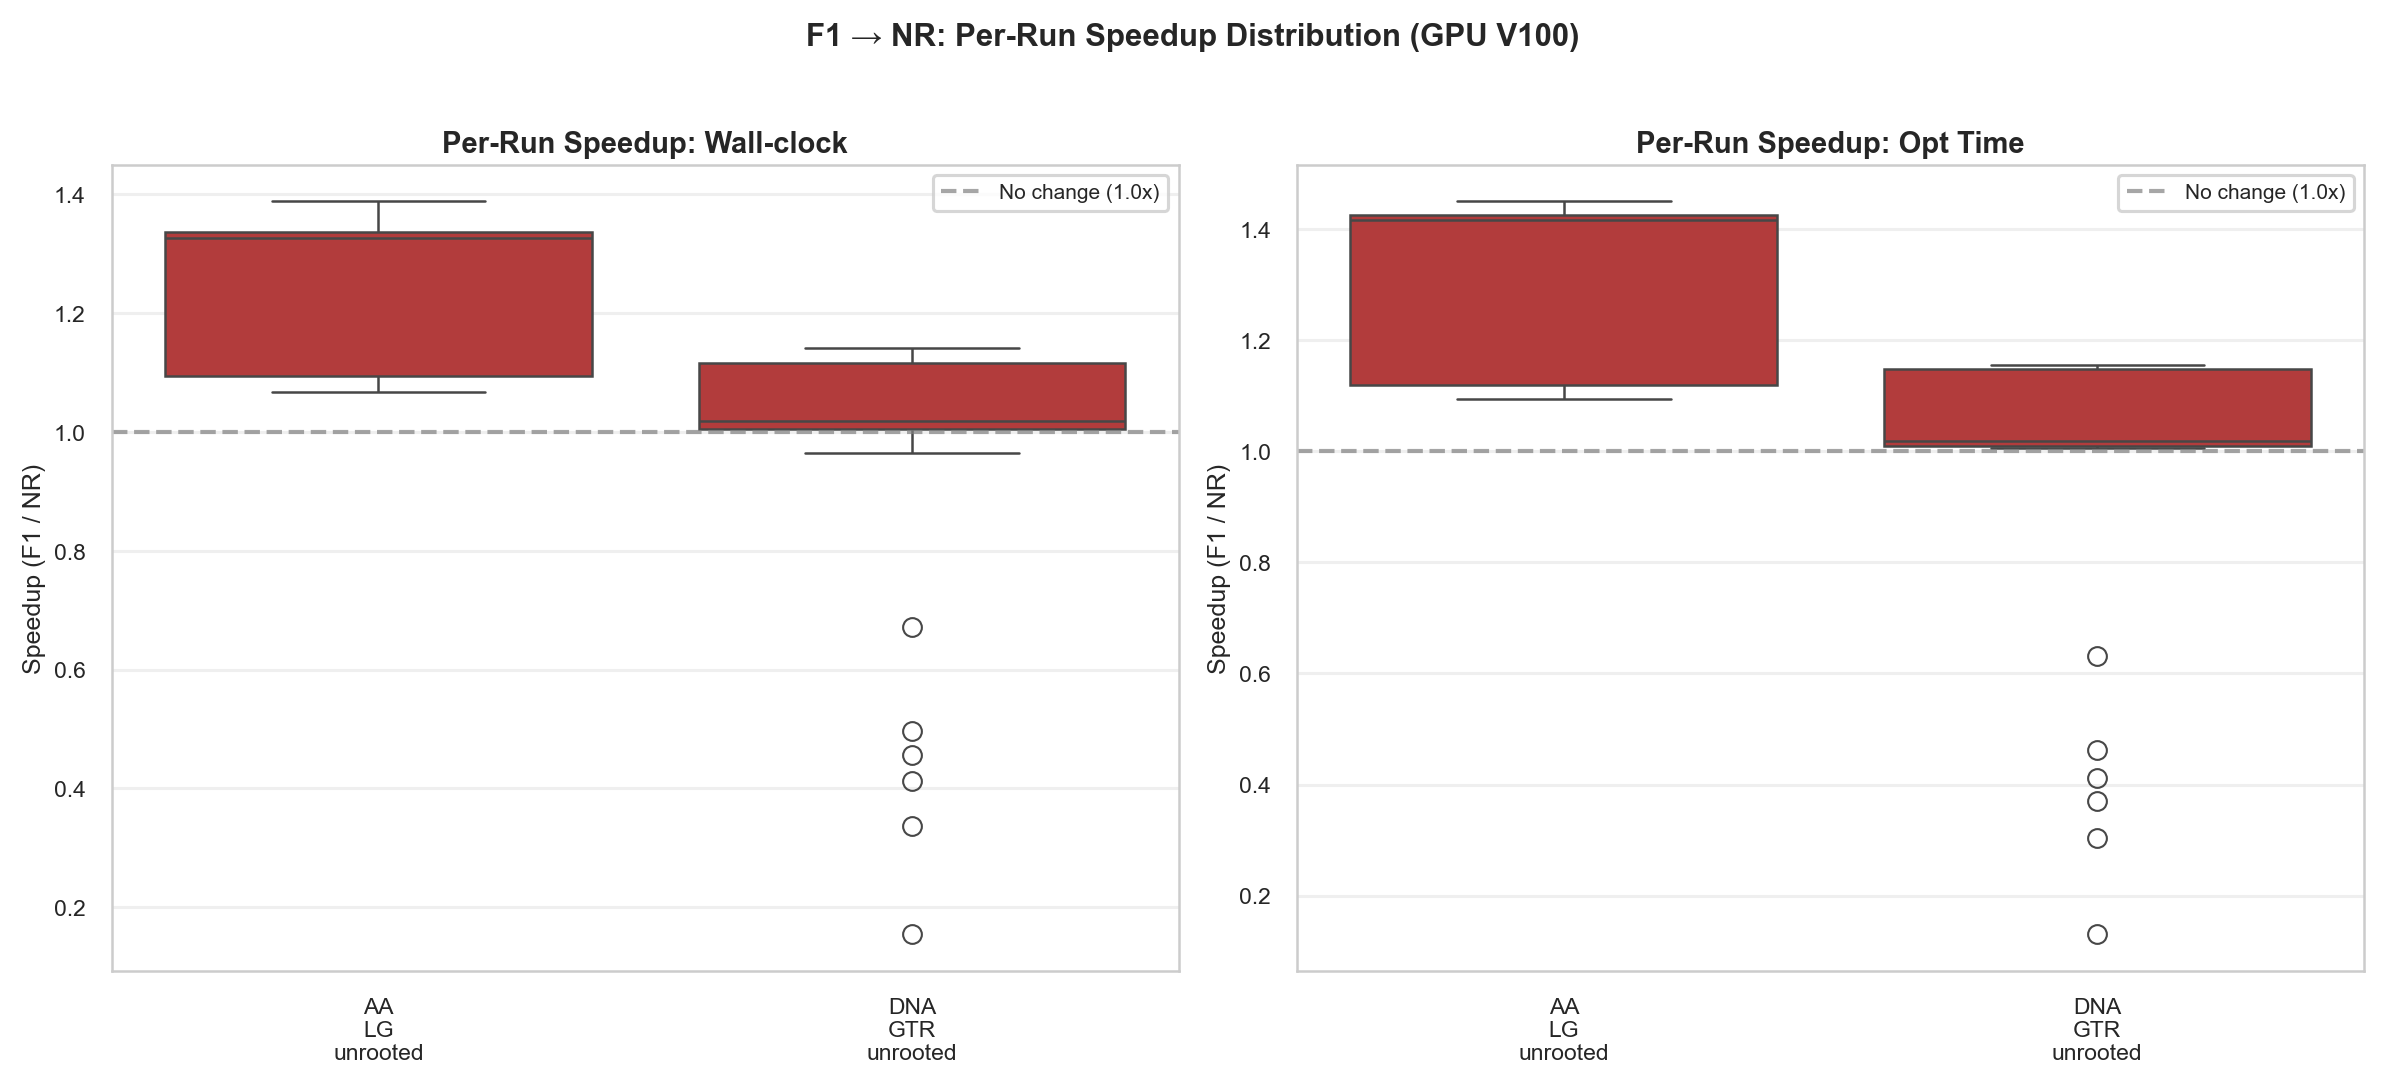

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, metric, title_suffix in [(ax1, 'wallclock_time', 'Wall-clock'), (ax2, 'opt_time', 'Opt Time')]:
    ratios_list = []
    combos = df_nr[['data_type','tree_type','model','backend']].drop_duplicates()

    for _, combo in combos.iterrows():
        dt, tt, model, backend = combo['data_type'], combo['tree_type'], combo['model'], combo['backend']
        for tree in sorted(df_nr[(df_nr['data_type']==dt) & (df_nr['model']==model)]['treefile'].unique()):
            for run in range(1, 11):
                f1_val = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                               (df_f1['model']==model) & (df_f1['backend']==backend) &
                               (df_f1['treefile']==tree) & (df_f1['run']==run)][metric]
                nr_val = df_nr[(df_nr['data_type']==dt) & (df_nr['tree_type']==tt) & 
                               (df_nr['model']==model) & (df_nr['backend']==backend) &
                               (df_nr['treefile']==tree) & (df_nr['run']==run)][metric]
                if len(f1_val) == 1 and len(nr_val) == 1:
                    ratio = f1_val.values[0] / nr_val.values[0]
                    ratios_list.append({
                        'combo': f'{dt}\n{model}\n{tt}',
                        'speedup': ratio
                    })

    df_ratios = pd.DataFrame(ratios_list)
    if not df_ratios.empty:
        sns.boxplot(data=df_ratios, x='combo', y='speedup', linewidth=1.2,
                    color='#C62828', ax=ax)
        ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='No change (1.0x)')
        ax.set_xlabel('')
        ax.set_ylabel(f'Speedup (F1 / NR)', fontsize=12)
        ax.set_title(f'Per-Run Speedup: {title_suffix}', fontsize=14, fontweight='bold')
        ax.grid(True, axis='y', alpha=0.3)
        ax.legend(fontsize=10)

plt.suptitle('F1 \u2192 NR: Per-Run Speedup Distribution (GPU V100)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_speedup_distribution.png", bbox_inches='tight', dpi=300)
plt.show()

# 10. Correctness: Log-likelihood comparison

In [12]:
print("=" * 70)
print("Correctness: Log-likelihood comparison (F1 vs NR)")
print("=" * 70)

all_match = True
max_diff_overall = 0.0
combos = df_nr[['data_type','tree_type','model']].drop_duplicates()

for _, combo in combos.iterrows():
    dt, tt, model = combo['data_type'], combo['tree_type'], combo['model']
    for tree in sorted(df_nr[(df_nr['data_type']==dt) & (df_nr['model']==model)]['treefile'].unique()):
        f1_lls = sorted(df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                           (df_f1['model']==model) & (df_f1['treefile']==tree)]['optimal_likelihood'].unique())
        nr_lls = sorted(df_nr[(df_nr['data_type']==dt) & (df_nr['tree_type']==tt) & 
                           (df_nr['model']==model) & (df_nr['treefile']==tree)]['optimal_likelihood'].unique())
        if set(f1_lls) != set(nr_lls):
            if len(f1_lls) == len(nr_lls):
                diffs = [abs(a - b) for a, b in zip(f1_lls, nr_lls)]
                max_d = max(diffs)
                max_diff_overall = max(max_diff_overall, max_d)
                if max_d > 0.01:
                    print(f"  DIFF {dt}/{model}/{tt}/{tree}: max_diff={max_d:.6f}")
                    print(f"    F1: {f1_lls}")
                    print(f"    NR: {nr_lls}")
                    if max_d > 1.0:
                        all_match = False
            else:
                print(f"  MISMATCH {dt}/{model}/{tt}/{tree}: F1 has {len(f1_lls)} unique, NR has {len(nr_lls)} unique")
                all_match = False

if all_match and max_diff_overall == 0.0:
    print("  All log-likelihoods match exactly (0.0 diff) across all trees and runs")
    print("  Correctness: VERIFIED")
elif all_match:
    print(f"  Max LL diff: {max_diff_overall:.6f}")
    if max_diff_overall < 0.01:
        print("  Correctness: VERIFIED (negligible floating-point differences)")
    elif max_diff_overall < 1.0:
        print("  Correctness: VERIFIED (minor differences, likely different NR convergence path)")
    else:
        print("  Correctness: WARNING — differences exceed 1.0, investigate!")
else:
    print(f"  WARNING: Significant LL mismatches detected! Max diff: {max_diff_overall:.6f}")

Correctness: Log-likelihood comparison (F1 vs NR)
  DIFF AA/LG/unrooted/tree_1: max_diff=44.547000
    F1: [-88901422.374]
    NR: [-88901466.921]
  DIFF AA/LG/unrooted/tree_10: max_diff=53.143000
    F1: [-86714228.485]
    NR: [-86714281.628]
  DIFF AA/LG/unrooted/tree_2: max_diff=47.612000
    F1: [-90504713.177]
    NR: [-90504760.789]
  DIFF AA/LG/unrooted/tree_3: max_diff=52.588000
    F1: [-87357001.171]
    NR: [-87357053.759]
  DIFF AA/LG/unrooted/tree_4: max_diff=52.361000
    F1: [-87712627.079]
    NR: [-87712679.44]
  DIFF AA/LG/unrooted/tree_5: max_diff=52.798000
    F1: [-86382770.364]
    NR: [-86382823.162]
  DIFF AA/LG/unrooted/tree_6: max_diff=49.855000
    F1: [-84301496.968]
    NR: [-84301546.823]
  DIFF AA/LG/unrooted/tree_7: max_diff=58.923000
    F1: [-87134163.126]
    NR: [-87134222.049]
  DIFF AA/LG/unrooted/tree_8: max_diff=48.491000
    F1: [-81931521.002]
    NR: [-81931569.493]
  DIFF AA/LG/unrooted/tree_9: max_diff=45.768000
    F1: [-82340194.25]
    N

# 10b. Log-Likelihood Comparison Plots

NR consistently finds slightly worse (more negative) optimal lnL than F1 across all trees.
This section visualizes the absolute differences, relative differences, and the direction of the bias.

In [13]:
# Build per-tree LL comparison dataframe
ll_rows = []
combos = df_nr[['data_type','tree_type','model']].drop_duplicates()

for _, combo in combos.iterrows():
    dt, tt, model = combo['data_type'], combo['tree_type'], combo['model']
    for tree in sorted(df_nr[(df_nr['data_type']==dt) & (df_nr['model']==model)]['treefile'].unique()):
        f1_ll = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                       (df_f1['model']==model) & (df_f1['treefile']==tree)]['optimal_likelihood']
        nr_ll = df_nr[(df_nr['data_type']==dt) & (df_nr['tree_type']==tt) & 
                       (df_nr['model']==model) & (df_nr['treefile']==tree)]['optimal_likelihood']
        if len(f1_ll) == 0 or len(nr_ll) == 0:
            continue
        # Each tree should have one unique LL (deterministic given fixed tree + model)
        f1_val = sorted(f1_ll.unique())[0]
        nr_val = sorted(nr_ll.unique())[0]
        abs_diff = nr_val - f1_val  # negative means NR is worse (more negative lnL)
        rel_diff_ppm = abs_diff / abs(f1_val) * 1e6  # parts per million
        ll_rows.append({
            'data_type': dt, 'model': model, 'tree_type': tt, 'tree': tree,
            'F1_lnL': f1_val, 'NR_lnL': nr_val,
            'abs_diff': abs_diff, 'abs_diff_mag': abs(abs_diff),
            'rel_diff_ppm': rel_diff_ppm,
            'label': f'{dt}/{model}'
        })

df_ll = pd.DataFrame(ll_rows)
print(f"Built LL comparison for {len(df_ll)} tree/model combinations")
print(f"\nDirection check — NR worse (diff < 0) in {(df_ll['abs_diff'] < 0).sum()}/{len(df_ll)} cases")
print(f"Absolute diff range: {df_ll['abs_diff_mag'].min():.2f} to {df_ll['abs_diff_mag'].max():.2f}")
print(f"Relative diff range: {df_ll['rel_diff_ppm'].abs().min():.3f} to {df_ll['rel_diff_ppm'].abs().max():.3f} ppm")

Built LL comparison for 20 tree/model combinations

Direction check — NR worse (diff < 0) in 20/20 cases
Absolute diff range: 39.89 to 64.12
Relative diff range: 0.501 to 0.913 ppm


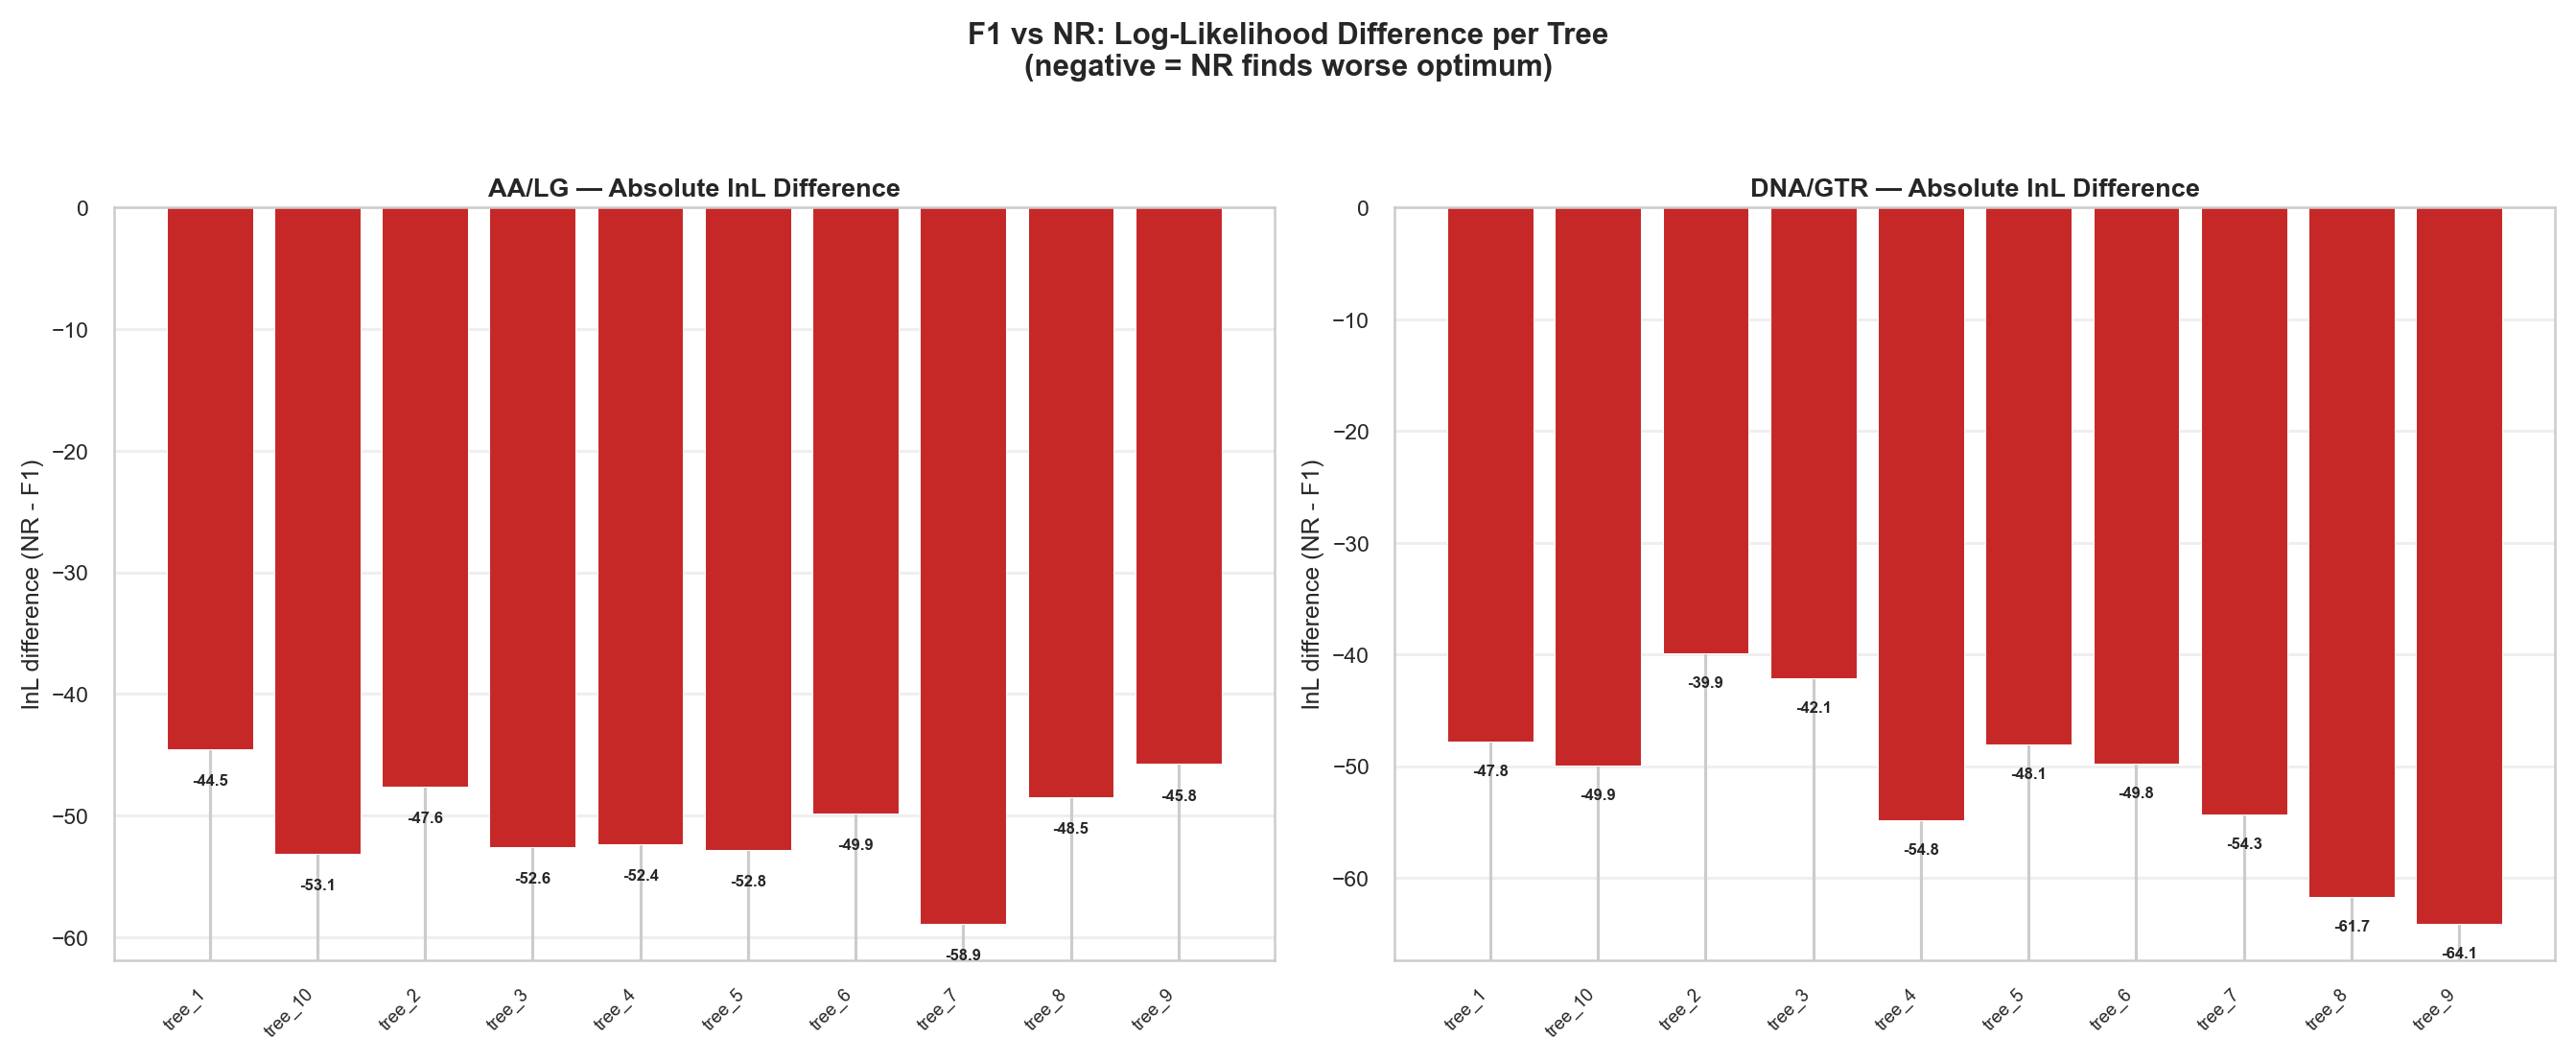

In [14]:
# Plot 1: Absolute LL difference per tree (bar chart)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, (label, group) in enumerate(df_ll.groupby('label')):
    ax = axes[idx]
    group_sorted = group.sort_values('tree')
    colors = ['#C62828' if d < 0 else '#2E7D32' for d in group_sorted['abs_diff']]
    bars = ax.bar(range(len(group_sorted)), group_sorted['abs_diff'], color=colors, 
                  edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(group_sorted)))
    ax.set_xticklabels(group_sorted['tree'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('lnL difference (NR - F1)', fontsize=12)
    ax.set_title(f'{label} — Absolute lnL Difference', fontsize=13, fontweight='bold')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.grid(True, axis='y', alpha=0.3)
    
    # Annotate bars
    for i, (_, row) in enumerate(group_sorted.iterrows()):
        ax.text(i, row['abs_diff'] - 2, f"{row['abs_diff']:.1f}", 
                ha='center', va='top', fontsize=8, fontweight='bold')

plt.suptitle('F1 vs NR: Log-Likelihood Difference per Tree\n(negative = NR finds worse optimum)', 
             fontsize=15, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_ll_abs_diff.png", bbox_inches='tight', dpi=300)
plt.show()

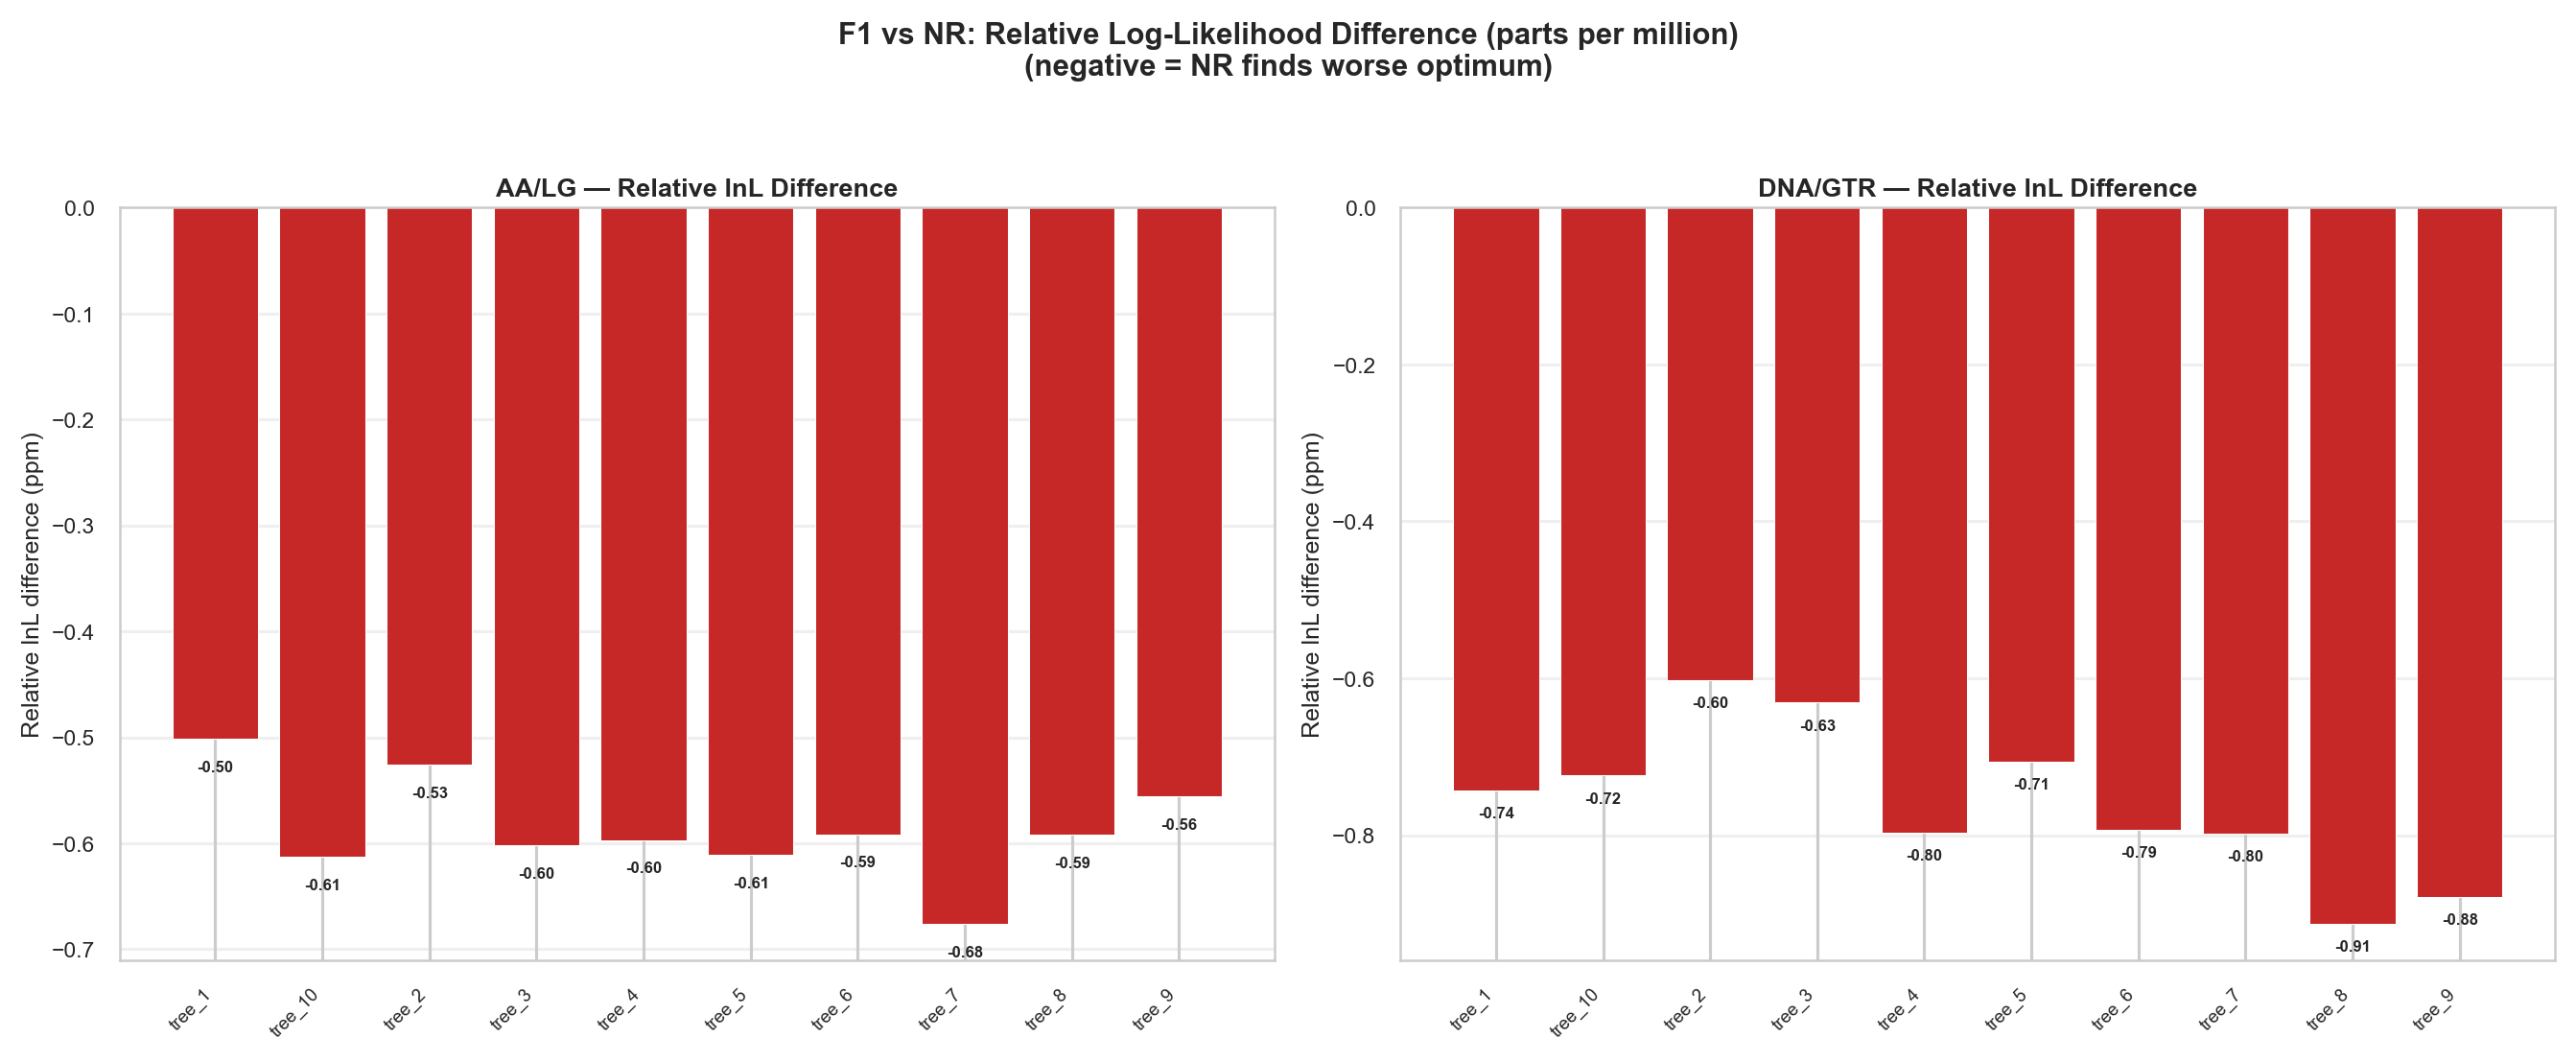

In [15]:
# Plot 2: Relative LL difference (parts per million) — shows how significant the diffs are
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, (label, group) in enumerate(df_ll.groupby('label')):
    ax = axes[idx]
    group_sorted = group.sort_values('tree')
    colors = ['#C62828' if d < 0 else '#2E7D32' for d in group_sorted['rel_diff_ppm']]
    bars = ax.bar(range(len(group_sorted)), group_sorted['rel_diff_ppm'], color=colors, 
                  edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(group_sorted)))
    ax.set_xticklabels(group_sorted['tree'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Relative lnL difference (ppm)', fontsize=12)
    ax.set_title(f'{label} — Relative lnL Difference', fontsize=13, fontweight='bold')
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.grid(True, axis='y', alpha=0.3)
    
    for i, (_, row) in enumerate(group_sorted.iterrows()):
        ax.text(i, row['rel_diff_ppm'] - 0.02, f"{row['rel_diff_ppm']:.2f}", 
                ha='center', va='top', fontsize=8, fontweight='bold')

plt.suptitle('F1 vs NR: Relative Log-Likelihood Difference (parts per million)\n(negative = NR finds worse optimum)', 
             fontsize=15, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_ll_rel_diff_ppm.png", bbox_inches='tight', dpi=300)
plt.show()

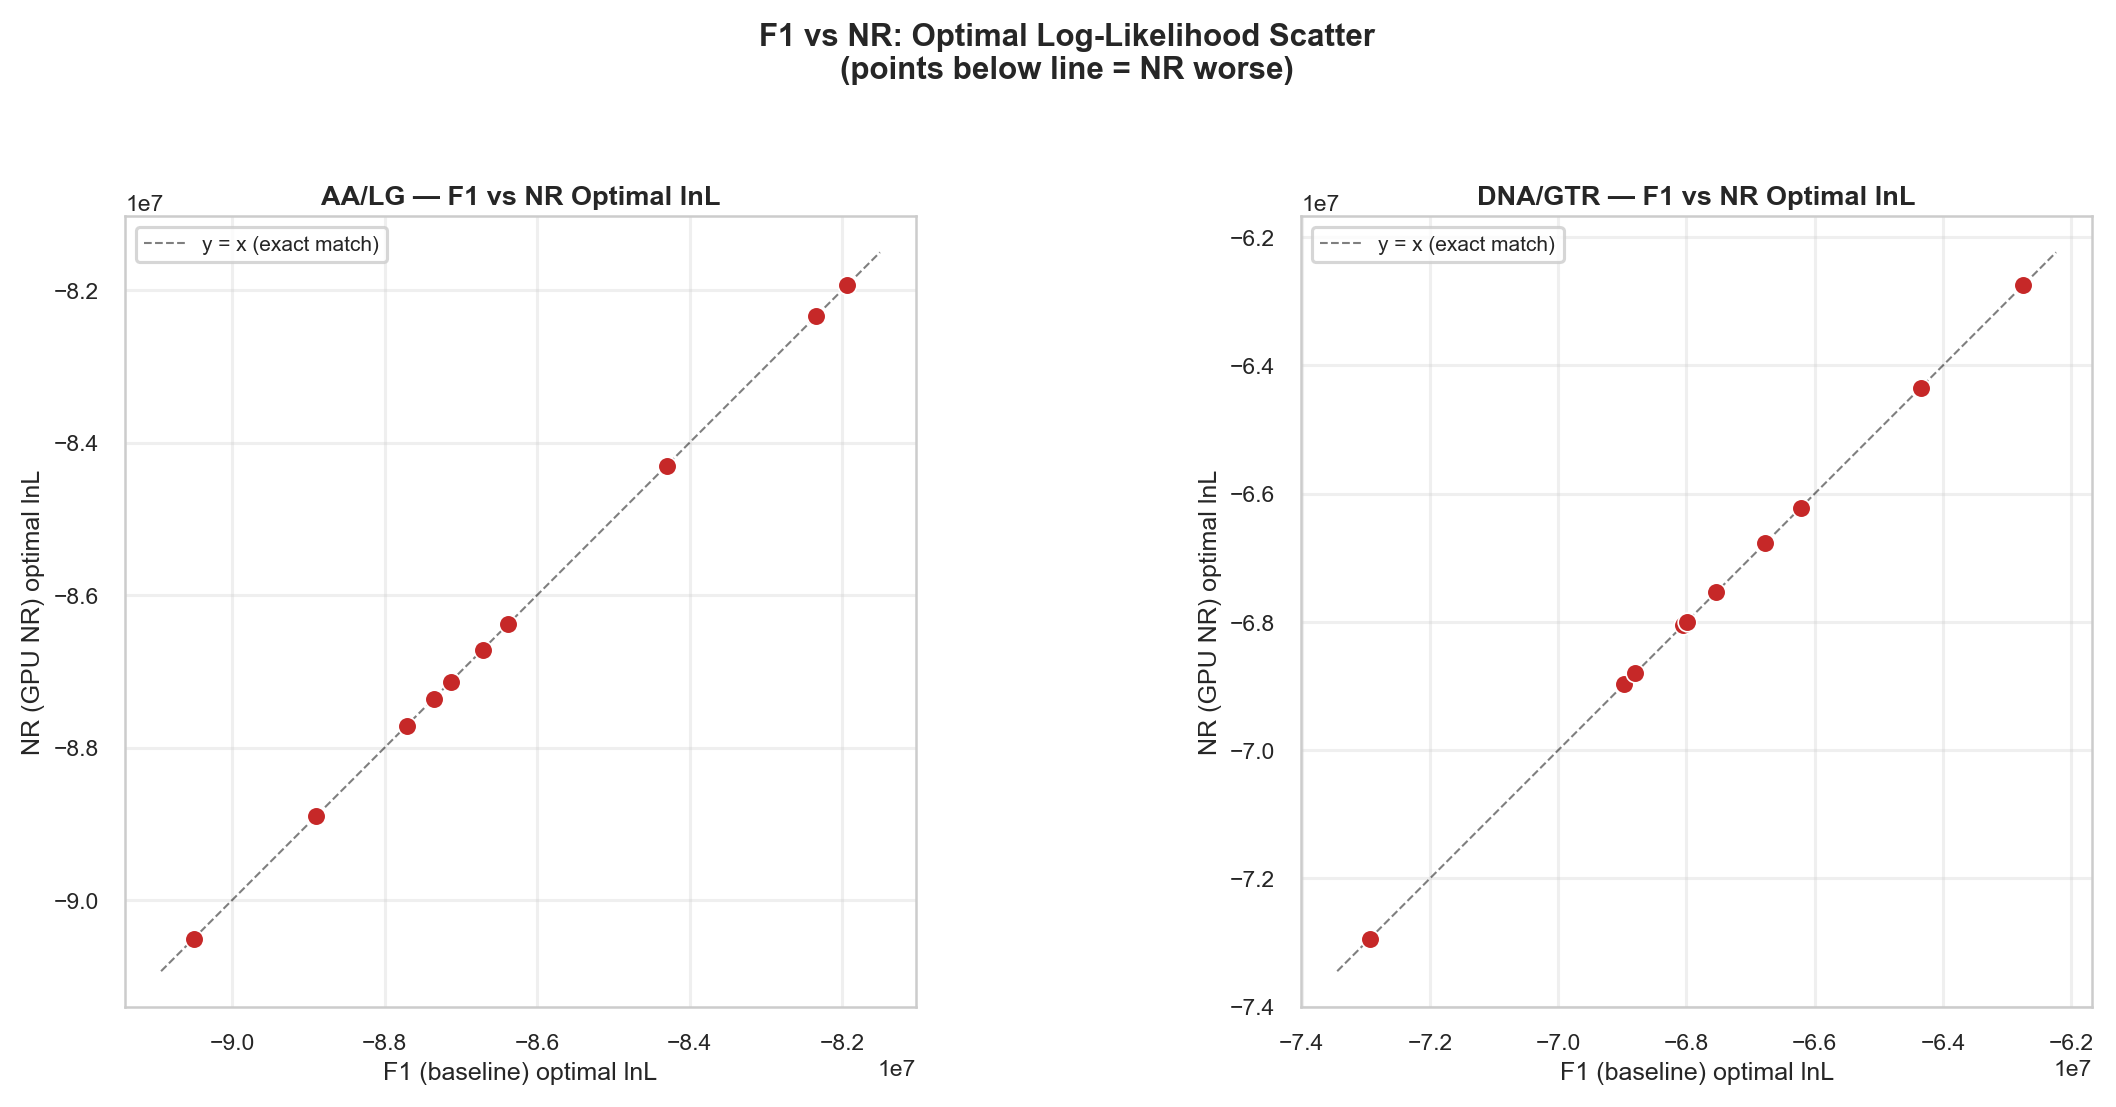

In [16]:
# Plot 3: Scatter — F1 lnL vs NR lnL with identity line
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for idx, (label, group) in enumerate(df_ll.groupby('label')):
    ax = axes[idx]
    ax.scatter(group['F1_lnL'], group['NR_lnL'], s=80, c='#C62828', edgecolors='white', 
               linewidth=0.8, zorder=3)
    
    # Identity line
    ll_min = min(group['F1_lnL'].min(), group['NR_lnL'].min())
    ll_max = max(group['F1_lnL'].max(), group['NR_lnL'].max())
    margin = (ll_max - ll_min) * 0.05
    ax.plot([ll_min - margin, ll_max + margin], [ll_min - margin, ll_max + margin], 
            'k--', alpha=0.5, linewidth=1, label='y = x (exact match)')
    
    ax.set_xlabel('F1 (baseline) optimal lnL', fontsize=12)
    ax.set_ylabel('NR (GPU NR) optimal lnL', fontsize=12)
    ax.set_title(f'{label} — F1 vs NR Optimal lnL', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('F1 vs NR: Optimal Log-Likelihood Scatter\n(points below line = NR worse)', 
             fontsize=15, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_ll_scatter.png", bbox_inches='tight', dpi=300)
plt.show()

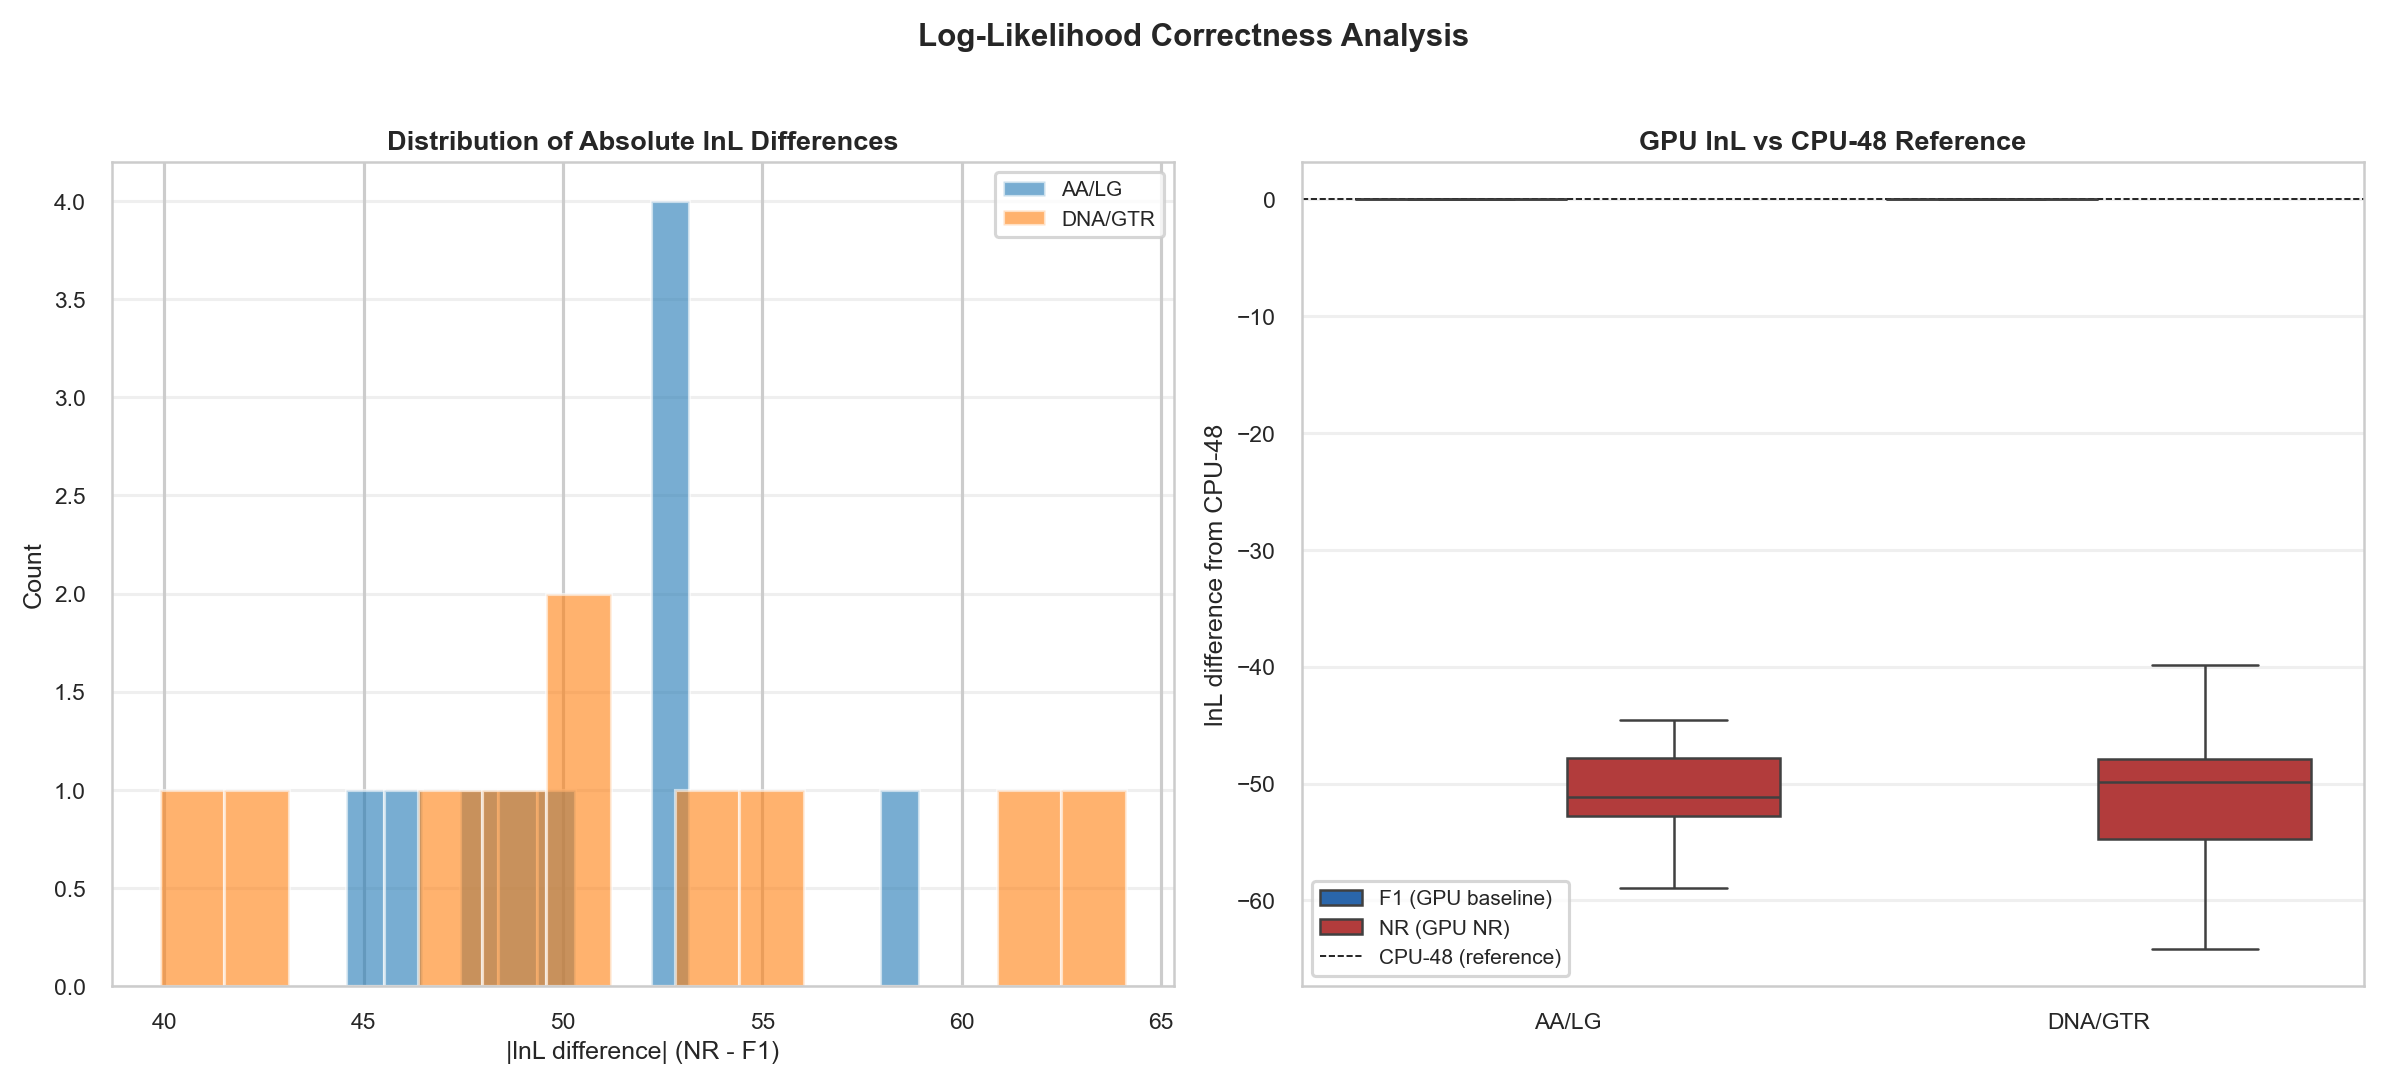

In [17]:
# Plot 4: Combined summary — abs diff distribution + CPU-48 vs NR vs F1 LL comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: Distribution of absolute diffs by model
for label, group in df_ll.groupby('label'):
    ax1.hist(group['abs_diff_mag'], bins=15, alpha=0.6, label=label, edgecolor='white')
ax1.set_xlabel('|lnL difference| (NR - F1)', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Distribution of Absolute lnL Differences', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, axis='y', alpha=0.3)

# Right: 3-way comparison with CPU-48 (if available)
# Show per-tree lnL for F1, NR, and CPU-48
rows_3way = []
for _, combo in combos.iterrows():
    dt, tt, model = combo['data_type'], combo['tree_type'], combo['model']
    for tree in sorted(df_nr[(df_nr['data_type']==dt) & (df_nr['model']==model)]['treefile'].unique()):
        f1_val = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                       (df_f1['model']==model) & (df_f1['treefile']==tree)]['optimal_likelihood']
        nr_val = df_nr[(df_nr['data_type']==dt) & (df_nr['tree_type']==tt) & 
                       (df_nr['model']==model) & (df_nr['treefile']==tree)]['optimal_likelihood']
        cpu_val = df_cpu[(df_cpu['data_type']==dt) & (df_cpu['tree_type']==tt) & 
                         (df_cpu['model']==model) & (df_cpu['treefile']==tree)]['optimal_likelihood']
        if len(f1_val) > 0:
            rows_3way.append({'label': f'{dt}/{model}', 'tree': tree, 'version': 'F1 (GPU baseline)', 
                              'lnL': sorted(f1_val.unique())[0]})
        if len(nr_val) > 0:
            rows_3way.append({'label': f'{dt}/{model}', 'tree': tree, 'version': 'NR (GPU NR)', 
                              'lnL': sorted(nr_val.unique())[0]})
        if len(cpu_val) > 0:
            rows_3way.append({'label': f'{dt}/{model}', 'tree': tree, 'version': 'CPU-48', 
                              'lnL': sorted(cpu_val.unique())[0]})

df_3way = pd.DataFrame(rows_3way)

# Show the diff from CPU-48 for each version
if len(df_3way) > 0 and 'CPU-48' in df_3way['version'].values:
    diff_rows = []
    for label in df_3way['label'].unique():
        for tree in df_3way[df_3way['label']==label]['tree'].unique():
            cpu_ll = df_3way[(df_3way['label']==label) & (df_3way['tree']==tree) & 
                             (df_3way['version']=='CPU-48')]['lnL']
            if len(cpu_ll) == 0:
                continue
            cpu_v = cpu_ll.values[0]
            for ver in ['F1 (GPU baseline)', 'NR (GPU NR)']:
                ver_ll = df_3way[(df_3way['label']==label) & (df_3way['tree']==tree) & 
                                 (df_3way['version']==ver)]['lnL']
                if len(ver_ll) > 0:
                    diff_rows.append({'label': label, 'tree': tree, 'version': ver, 
                                      'diff_from_cpu': ver_ll.values[0] - cpu_v})

    df_diff_cpu = pd.DataFrame(diff_rows)
    if not df_diff_cpu.empty:
        palette_3way = {'F1 (GPU baseline)': '#1565C0', 'NR (GPU NR)': '#C62828'}
        sns.boxplot(data=df_diff_cpu, x='label', y='diff_from_cpu', hue='version',
                    palette=palette_3way, linewidth=1.2, ax=ax2)
        ax2.axhline(y=0, color='black', linewidth=0.8, linestyle='--', label='CPU-48 (reference)')
        ax2.set_xlabel('')
        ax2.set_ylabel('lnL difference from CPU-48', fontsize=12)
        ax2.set_title('GPU lnL vs CPU-48 Reference', fontsize=13, fontweight='bold')
        ax2.legend(fontsize=10)
        ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle('Log-Likelihood Correctness Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_ll_summary.png", bbox_inches='tight', dpi=300)
plt.show()

In [18]:
# Detailed per-tree LL comparison table
print("=" * 110)
print("DETAILED LOG-LIKELIHOOD COMPARISON: F1 vs NR vs CPU-48")
print("=" * 110)

for label in sorted(df_ll['label'].unique()):
    group = df_ll[df_ll['label']==label].sort_values('tree')
    dt = group.iloc[0]['data_type']
    tt = group.iloc[0]['tree_type']
    model = group.iloc[0]['model']
    
    print(f"\n  {label} ({tt})")
    print(f"  {'Tree':<10} {'F1 lnL':>20} {'NR lnL':>20} {'CPU-48 lnL':>20} {'NR-F1':>12} {'NR-CPU':>12} {'ppm':>8}")
    print(f"  {'-'*10} {'-'*20} {'-'*20} {'-'*20} {'-'*12} {'-'*12} {'-'*8}")
    
    for _, row in group.iterrows():
        cpu_sub = df_cpu[(df_cpu['data_type']==dt) & (df_cpu['tree_type']==tt) & 
                         (df_cpu['model']==model) & (df_cpu['treefile']==row['tree'])]
        cpu_str = f"{sorted(cpu_sub['optimal_likelihood'].unique())[0]:>20.3f}" if len(cpu_sub) > 0 else f"{'N/A':>20}"
        nr_cpu_diff = ""
        if len(cpu_sub) > 0:
            cpu_val = sorted(cpu_sub['optimal_likelihood'].unique())[0]
            nr_cpu_diff = f"{row['NR_lnL'] - cpu_val:>+12.3f}"
        
        print(f"  {row['tree']:<10} {row['F1_lnL']:>20.3f} {row['NR_lnL']:>20.3f} {cpu_str} "
              f"{row['abs_diff']:>+12.3f} {nr_cpu_diff:>12} {row['rel_diff_ppm']:>8.3f}")
    
    print(f"  {'-'*10} {'-'*20} {'-'*20} {'-'*20} {'-'*12} {'-'*12} {'-'*8}")
    print(f"  {'MEAN':<10} {'':>20} {'':>20} {'':>20} "
          f"{group['abs_diff'].mean():>+12.3f} {'':>12} {group['rel_diff_ppm'].mean():>8.3f}")
    print(f"  {'RANGE':<10} {'':>20} {'':>20} {'':>20} "
          f"[{group['abs_diff'].min():.1f}, {group['abs_diff'].max():.1f}]")

print(f"\n{'='*110}")
print("KEY OBSERVATIONS:")
print(f"  - NR is ALWAYS worse (all diffs negative): {(df_ll['abs_diff'] < 0).all()}")
print(f"  - Mean absolute diff: AA={df_ll[df_ll['label']=='AA/LG']['abs_diff_mag'].mean():.1f}, "
      f"DNA={df_ll[df_ll['label']=='DNA/GTR']['abs_diff_mag'].mean():.1f}")
print(f"  - Mean relative diff: AA={df_ll[df_ll['label']=='AA/LG']['rel_diff_ppm'].abs().mean():.3f} ppm, "
      f"DNA={df_ll[df_ll['label']=='DNA/GTR']['rel_diff_ppm'].abs().mean():.3f} ppm")
print(f"  - This suggests NR converges to a slightly different (worse) local optimum,")
print(f"    likely due to different floating-point accumulation order in the fused NR loop")

DETAILED LOG-LIKELIHOOD COMPARISON: F1 vs NR vs CPU-48

  AA/LG (unrooted)
  Tree                     F1 lnL               NR lnL           CPU-48 lnL        NR-F1       NR-CPU      ppm
  ---------- -------------------- -------------------- -------------------- ------------ ------------ --------
  tree_1            -88901422.374        -88901466.921        -88901422.374      -44.547      -44.547   -0.501
  tree_10           -86714228.485        -86714281.628        -86714228.485      -53.143      -53.143   -0.613
  tree_2            -90504713.177        -90504760.789        -90504713.177      -47.612      -47.612   -0.526
  tree_3            -87357001.171        -87357053.759        -87357001.171      -52.588      -52.588   -0.602
  tree_4            -87712627.079        -87712679.440        -87712627.079      -52.361      -52.361   -0.597
  tree_5            -86382770.364        -86382823.162        -86382770.364      -52.798      -52.798   -0.611
  tree_6            -84301496.968    

# 11. GPU vs CPU-48 overall standing

In [19]:
print("=" * 70)
print("GPU vs CPU-48 overall standing (NR GPU vs CPU-48)")
print("=" * 70)

combos = df_nr[['data_type','tree_type','model']].drop_duplicates()

print(f"{'Model':<20} {'GPU NR med':>12} {'CPU-48 med':>12} {'GPU/CPU':>10} {'Status':>15}")
print(f"{'-'*20} {'-'*12} {'-'*12} {'-'*10} {'-'*15}")

for _, combo in combos.iterrows():
    dt, tt, model = combo['data_type'], combo['tree_type'], combo['model']
    nr_med = df_nr[(df_nr['data_type']==dt) & (df_nr['tree_type']==tt) & 
                   (df_nr['model']==model)]['wallclock_time'].median()
    cpu_sub = df_cpu[(df_cpu['data_type']==dt) & (df_cpu['tree_type']==tt) & 
                     (df_cpu['model']==model)]
    if len(cpu_sub) > 0:
        cpu_med = cpu_sub['wallclock_time'].median()
        ratio = nr_med / cpu_med
        status = f"{1/ratio:.2f}x FASTER" if ratio < 1 else f"{ratio:.2f}x slower"
        label = f"{dt}/{model} ({tt})"
        print(f"{label:<20} {nr_med:>12.3f} {cpu_med:>12.3f} {ratio:>10.2f} {status:>15}")
    else:
        label = f"{dt}/{model} ({tt})"
        print(f"{label:<20} {nr_med:>12.3f} {'N/A':>12} {'N/A':>10} {'no CPU data':>15}")

# Also show opt_time comparison
print(f"\n{'Model':<20} {'GPU opt_med':>12} {'CPU opt_med':>12} {'GPU/CPU':>10} {'Status':>15}")
print(f"{'-'*20} {'-'*12} {'-'*12} {'-'*10} {'-'*15}")

for _, combo in combos.iterrows():
    dt, tt, model = combo['data_type'], combo['tree_type'], combo['model']
    nr_opt = df_nr[(df_nr['data_type']==dt) & (df_nr['tree_type']==tt) & 
                   (df_nr['model']==model)]['opt_time'].median()
    cpu_sub = df_cpu[(df_cpu['data_type']==dt) & (df_cpu['tree_type']==tt) & 
                     (df_cpu['model']==model)]
    if len(cpu_sub) > 0:
        cpu_opt = cpu_sub['opt_time'].median()
        ratio = nr_opt / cpu_opt
        status = f"{1/ratio:.2f}x FASTER" if ratio < 1 else f"{ratio:.2f}x slower"
        label = f"{dt}/{model} ({tt})"
        print(f"{label:<20} {nr_opt:>12.3f} {cpu_opt:>12.3f} {ratio:>10.2f} {status:>15}")
    else:
        label = f"{dt}/{model} ({tt})"
        print(f"{label:<20} {nr_opt:>12.3f} {'N/A':>12} {'N/A':>10} {'no CPU data':>15}")

GPU vs CPU-48 overall standing (NR GPU vs CPU-48)
Model                  GPU NR med   CPU-48 med    GPU/CPU          Status
-------------------- ------------ ------------ ---------- ---------------
AA/LG (unrooted)           14.072       15.169       0.93    1.08x FASTER
DNA/GTR (unrooted)         15.607       13.973       1.12    1.12x slower

Model                 GPU opt_med  CPU opt_med    GPU/CPU          Status
-------------------- ------------ ------------ ---------- ---------------
AA/LG (unrooted)           11.218       13.745       0.82    1.23x FASTER
DNA/GTR (unrooted)         12.639       12.892       0.98    1.02x FASTER


# 12. Historical progression

In [20]:
# Load all historical GPU results to show progression
hist_paths = {
    'T2 (initial)': '/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation_opt',
    'B1 (buffer)': '/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation_buffer',
    'F1 (fused)': '/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation_fused',
    'NR (GPU NR)': '/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation_gpu_NR',
}

hist_dfs = {}
for label, path in hist_paths.items():
    if os.path.exists(path):
        df = parse_all_logs(path, label)
        hist_dfs[label] = df

print("\n" + "=" * 80)
print("HISTORICAL PROGRESSION: GPU wallclock median (s)")
print("=" * 80)

for dt_model in [('AA', 'LG', 'unrooted'), ('DNA', 'GTR', 'unrooted')]:
    dt, model, tt = dt_model
    print(f"\n  {dt}/{model} ({tt}):")
    for label in hist_paths.keys():
        if label in hist_dfs:
            df = hist_dfs[label]
            sub = df[(df['data_type']==dt) & (df['tree_type']==tt) & 
                     (df['model']==model) & (df['backend']=='GPU_V100')]
            if len(sub) > 0:
                wc_med = sub['wallclock_time'].median()
                opt_med = sub['opt_time'].median()
                print(f"    {label:<20} wallclock={wc_med:>8.3f}s  opt_time={opt_med:>8.3f}s")

[T2 (initial)] Parsed 200 log files (0 skipped)
[B1 (buffer)] Parsed 200 log files (0 skipped)
[F1 (fused)] Parsed 200 log files (0 skipped)
[NR (GPU NR)] Parsed 196 log files (1 skipped)

HISTORICAL PROGRESSION: GPU wallclock median (s)

  AA/LG (unrooted):
    T2 (initial)         wallclock=  18.230s  opt_time=  15.380s
    B1 (buffer)          wallclock=  18.239s  opt_time=  15.388s
    F1 (fused)           wallclock=  18.697s  opt_time=  15.838s
    NR (GPU NR)          wallclock=  14.072s  opt_time=  11.218s

  DNA/GTR (unrooted):
    T2 (initial)         wallclock=  17.301s  opt_time=  14.503s
    B1 (buffer)          wallclock=  17.242s  opt_time=  14.490s
    F1 (fused)           wallclock=  17.248s  opt_time=  14.508s
    NR (GPU NR)          wallclock=  15.607s  opt_time=  12.639s


# 13. Summary

In [21]:
print("=" * 70)
print("SUMMARY: NR \u2014 GPU-side Newton-Raphson (Fast NR Inner Loop)")
print("=" * 70)
print()
print("Change: Fused Newton-Raphson loop eliminates per-iteration overhead:")
print("  1. computeTraversalInfo called ONCE (not per NR step)")
print("  2. uploadEigenToGPU called ONCE (not per NR step)")
print("  3. TIP-INT P(t) computed on GPU (was host + upload)")
print("  4. Tip derivative tables computed on GPU (computeTipDerivTablesOnGPU)")
print("  5. NR loop inlined with identical convergence criteria")
print()

combos = df_nr[['data_type','tree_type','model','backend']].drop_duplicates()
print(f"{'Model':<20} {'F1 wc_med':>12} {'NR wc_med':>12} {'WC change':>10} | {'F1 opt_med':>12} {'NR opt_med':>12} {'Opt change':>10}")
print(f"{'-'*20} {'-'*12} {'-'*12} {'-'*10} | {'-'*12} {'-'*12} {'-'*10}")

for _, combo in combos.iterrows():
    dt, tt, model, backend = combo['data_type'], combo['tree_type'], combo['model'], combo['backend']
    f1_wc_med = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                   (df_f1['model']==model) & (df_f1['backend']==backend)]['wallclock_time'].median()
    nr_wc_med = df_nr[(df_nr['data_type']==dt) & (df_nr['tree_type']==tt) & 
                   (df_nr['model']==model) & (df_nr['backend']==backend)]['wallclock_time'].median()
    f1_opt_med = df_f1[(df_f1['data_type']==dt) & (df_f1['tree_type']==tt) & 
                   (df_f1['model']==model) & (df_f1['backend']==backend)]['opt_time'].median()
    nr_opt_med = df_nr[(df_nr['data_type']==dt) & (df_nr['tree_type']==tt) & 
                   (df_nr['model']==model) & (df_nr['backend']==backend)]['opt_time'].median()
    wc_pct = (nr_wc_med - f1_wc_med) / f1_wc_med * 100
    opt_pct = (nr_opt_med - f1_opt_med) / f1_opt_med * 100
    label = f"{dt}/{model} ({tt})"
    print(f"{label:<20} {f1_wc_med:>12.3f} {nr_wc_med:>12.3f} {wc_pct:>+9.1f}% | {f1_opt_med:>12.3f} {nr_opt_med:>12.3f} {opt_pct:>+9.1f}%")

print()
print("GPU vs CPU-48 standing:")
for _, combo in combos.iterrows():
    dt, tt, model, backend = combo['data_type'], combo['tree_type'], combo['model'], combo['backend']
    nr_wc_med = df_nr[(df_nr['data_type']==dt) & (df_nr['tree_type']==tt) & 
                   (df_nr['model']==model) & (df_nr['backend']==backend)]['wallclock_time'].median()
    cpu_sub = df_cpu[(df_cpu['data_type']==dt) & (df_cpu['tree_type']==tt) & 
                     (df_cpu['model']==model)]
    if len(cpu_sub) > 0:
        cpu_med = cpu_sub['wallclock_time'].median()
        ratio = nr_wc_med / cpu_med
        label = f"{dt}/{model} ({tt})"
        print(f"  {label}: GPU={nr_wc_med:.2f}s, CPU-48={cpu_med:.2f}s, ratio={ratio:.2f}x")
    else:
        label = f"{dt}/{model} ({tt})"
        print(f"  {label}: GPU={nr_wc_med:.2f}s, CPU-48=N/A")

SUMMARY: NR — GPU-side Newton-Raphson (Fast NR Inner Loop)

Change: Fused Newton-Raphson loop eliminates per-iteration overhead:
  1. computeTraversalInfo called ONCE (not per NR step)
  2. uploadEigenToGPU called ONCE (not per NR step)
  3. TIP-INT P(t) computed on GPU (was host + upload)
  4. Tip derivative tables computed on GPU (computeTipDerivTablesOnGPU)
  5. NR loop inlined with identical convergence criteria

Model                   F1 wc_med    NR wc_med  WC change |   F1 opt_med   NR opt_med Opt change
-------------------- ------------ ------------ ---------- | ------------ ------------ ----------
AA/LG (unrooted)           18.697       14.072     -24.7% |       15.838       11.218     -29.2%
DNA/GTR (unrooted)         17.248       15.607      -9.5% |       14.508       12.639     -12.9%

GPU vs CPU-48 standing:
  AA/LG (unrooted): GPU=14.07s, CPU-48=15.17s, ratio=0.93x
  DNA/GTR (unrooted): GPU=15.61s, CPU-48=13.97s, ratio=1.12x
